In [33]:
import os, random, time
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import distance_transform_edt, binary_dilation

# --- Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)
torch.backends.cudnn.benchmark = True

# --- Global Config ---
data_dir          = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
device            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
patch_size        = (96, 96, 96)
num_epochs        = 25
patches_per_patient = 4
save_path         = "/kaggle/working/MSA_ResUNet3D_best.pth"

BRATS_COLORS  = ['black', '#E74C3C', '#2ECC71', '#F1C40F']
BRATS_LABELS  = ['Background', 'NCR/NEC (cls 1)', 'Edema (cls 2)', 'Enh. Tumor (cls 3)']
brats_cmap    = ListedColormap(BRATS_COLORS)
brats_norm    = BoundaryNorm([0, 1, 2, 3, 4], brats_cmap.N)

print(f"Device : {device}")
print(f"GPUs   : {torch.cuda.device_count()}")
print(f"Patch  : {patch_size}")
print(f"Epochs : {num_epochs}")


Device : cuda
GPUs   : 2
Patch  : (96, 96, 96)
Epochs : 25


In [34]:
class BraTSDataset(Dataset):
    def __init__(self, data_dir, cache=True):
        self.data_dir = data_dir
        self.do_cache = cache
        self._cache = {}
        self.valid_patients = sorted([
            p for p in os.listdir(data_dir)
            if os.path.isdir(os.path.join(data_dir, p)) and p.startswith("BraTS20")
        ])
        self.valid_patients = [p for p in self.valid_patients if self._has_all_files(p)]
        print(f"Found {len(self.valid_patients)} valid patients.")

    def _has_all_files(self, patient):
        files = os.listdir(os.path.join(self.data_dir, patient))
        return all(any(r in f.lower() for f in files) for r in ["flair","t1","t1ce","t2","seg"])

    def __len__(self):
        return len(self.valid_patients)

    def _load(self, idx):
        patient = self.valid_patients[idx]
        path    = os.path.join(self.data_dir, patient)
        files   = os.listdir(path)
        def find_file(kw):
            for f in files:
                if kw in f.lower(): return os.path.join(path, f)
            raise FileNotFoundError(f"Missing: {kw}")
        flair = nib.load(find_file("flair")).get_fdata()
        t1    = nib.load(find_file("t1.nii")).get_fdata()
        t1ce  = nib.load(find_file("t1ce")).get_fdata()
        t2    = nib.load(find_file("t2")).get_fdata()
        mask  = nib.load(find_file("seg")).get_fdata()
        mask[mask == 4] = 3
        image = np.stack([flair, t1, t1ce, t2], axis=0)
        for i in range(4):
            brain = image[i] > 0
            if brain.any():
                image[i][brain] = (image[i][brain] - image[i][brain].mean()) / (image[i][brain].std() + 1e-5)
        return image, mask

    def __getitem__(self, idx):
        if self.do_cache and idx in self._cache:
            img16, msk8 = self._cache[idx]
            return torch.from_numpy(img16.astype(np.float32)), torch.from_numpy(msk8.astype(np.int64))
        image, mask = self._load(idx)
        if self.do_cache:
            self._cache[idx] = (image.astype(np.float16), mask.astype(np.uint8))
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [35]:
def extract_patch(image, mask, patch_size=(96,96,96), tumor_ratio=0.7):
    _, D, H, W = image.shape
    pd, ph, pw = patch_size
    if np.random.random() < tumor_ratio:
        tumor_coords = np.argwhere(mask.numpy() > 0)
        if len(tumor_coords) > 0:
            c = tumor_coords[np.random.randint(len(tumor_coords))]
            d = int(np.clip(c[0] - pd//2, 0, D - pd))
            h = int(np.clip(c[1] - ph//2, 0, H - ph))
            w = int(np.clip(c[2] - pw//2, 0, W - pw))
        else:
            d, h, w = [np.random.randint(0, max(1, s - ps + 1)) for s, ps in zip([D,H,W],[pd,ph,pw])]
    else:
        d, h, w = [np.random.randint(0, max(1, s - ps + 1)) for s, ps in zip([D,H,W],[pd,ph,pw])]
    return image[:, d:d+pd, h:h+ph, w:w+pw], mask[d:d+pd, h:h+ph, w:w+pw]

def augment_patch(img, mask):
    for img_dim, mask_dim in [(1,0), (2,1), (3,2)]:
        if torch.rand(1) > 0.5:
            img  = torch.flip(img,  dims=[img_dim])
            mask = torch.flip(mask, dims=[mask_dim])
    if torch.rand(1) > 0.5:
        scale = 1.0 + (torch.rand(img.shape[0], 1, 1, 1) - 0.5) * 0.2
        img = img * scale
    if torch.rand(1) > 0.5:
        img = img + torch.randn_like(img) * 0.05
    return img, mask

In [36]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch, affine=True)
        )
        self.shortcut = nn.Conv3d(in_ch, out_ch, 1)
        self.act      = nn.LeakyReLU(0.01, inplace=True)
    def forward(self, x):
        return self.act(self.conv(x) + self.shortcut(x))

class MultiScaleAttention(nn.Module):
    def __init__(self, in_ch, gating_ch):
        super().__init__()
        self.conv1   = nn.Conv3d(in_ch, in_ch, 1)
        self.conv3   = nn.Conv3d(in_ch, in_ch, 3, padding=1)
        self.dilated = nn.Conv3d(in_ch, in_ch, 3, padding=2, dilation=2)
        self.fusion  = nn.Conv3d(in_ch * 3, in_ch, 1)
        self.gate    = nn.Conv3d(gating_ch, in_ch, 1)
        self.psi     = nn.Conv3d(in_ch, 1, 1)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x, g):
        f = self.fusion(torch.cat([self.conv1(x), self.conv3(x), self.dilated(x)], dim=1))
        g = self.gate(g)
        if g.shape[2:] != f.shape[2:]:
            g = F.interpolate(g, size=f.shape[2:], mode='trilinear', align_corners=False)
        return x * self.sigmoid(self.psi(self.relu(f + g)))

class MSA_ResUNet3D(nn.Module):
    def __init__(self, dropout_p=0.1, deep_sup=True):
        super().__init__()
        self.deep_sup = deep_sup
        self.enc1, self.pool1 = ResBlock(4,  32),  nn.MaxPool3d(2)
        self.enc2, self.pool2 = ResBlock(32, 64),  nn.MaxPool3d(2)
        self.enc3, self.pool3 = ResBlock(64, 128), nn.MaxPool3d(2)
        self.bottleneck = ResBlock(128, 256)
        self.drop       = nn.Dropout3d(p=dropout_p)
        self.att3 = MultiScaleAttention(128, 256)
        self.att2 = MultiScaleAttention(64,  128)
        self.att1 = MultiScaleAttention(32,  64)
        self.up3, self.dec3 = nn.ConvTranspose3d(256, 128, 2, stride=2), ResBlock(256, 128)
        self.up2, self.dec2 = nn.ConvTranspose3d(128, 64,  2, stride=2), ResBlock(128, 64)
        self.up1, self.dec1 = nn.ConvTranspose3d(64,  32,  2, stride=2), ResBlock(64,  32)
        self.final = nn.Conv3d(32, 4, 1)
        if deep_sup:
            self.ds3 = nn.Conv3d(128, 4, 1)
            self.ds2 = nn.Conv3d(64,  4, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.drop(self.bottleneck(self.pool3(e3)))
        d3 = self.dec3(torch.cat([self.up3(b),  self.att3(e3, b)],  dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.att2(e2, d3)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.att1(e1, d2)], dim=1))
        out = self.final(d1)
        if self.training and self.deep_sup:
            return out, self.ds3(d3), self.ds2(d2)
        return out

In [37]:
class DiceCELoss(nn.Module):
    def __init__(self, ce_weight=None, smooth=1e-5):
        super().__init__()
        self.ce     = nn.CrossEntropyLoss(weight=ce_weight)
        self.smooth = smooth
    def forward(self, pred, target):
        ce_loss       = self.ce(pred, target)
        pred_soft     = F.softmax(pred, dim=1)
        target_onehot = F.one_hot(target, 4).permute(0,4,1,2,3).float()
        inter  = torch.sum(pred_soft * target_onehot, dim=(2,3,4))
        union  = torch.sum(pred_soft, dim=(2,3,4)) + torch.sum(target_onehot, dim=(2,3,4))
        dice_l = 1. - ((2.*inter + self.smooth) / (union + self.smooth)).mean()
        return ce_loss + dice_l

def dice_score(pred, target, num_classes=4, smooth=1e-5):
    """Mean Dice across FOREGROUND classes only (excludes background)."""
    pred = torch.argmax(pred, dim=1)
    dice = 0.0
    for cls in range(1, num_classes):  # FIXED: skip background
        p = (pred   == cls).float()
        t = (target == cls).float()
        dice += (2.*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)
    return dice / (num_classes - 1)

def brats_dice(pred_logits, target, smooth=1e-5):
    pred = torch.argmax(pred_logits, dim=1)
    def rd(pm, tm):
        return ((2.*(pm*tm).sum() + smooth) / (pm.sum() + tm.sum() + smooth)).item()
    return (
        rd((pred > 0).float(),            (target > 0).float()),
        rd(((pred==1)|(pred==3)).float(),  ((target==1)|(target==3)).float()),
        rd((pred==3).float(),              (target==3).float())
    )

def hausdorff_95(pred_mask, gt_mask):
    """95th percentile Hausdorff distance."""
    if pred_mask.sum() == 0 or gt_mask.sum() == 0:
        return float('nan')
    pred_dt = distance_transform_edt(~pred_mask)
    gt_dt   = distance_transform_edt(~gt_mask)
    return max(np.percentile(pred_dt[gt_mask > 0], 95),
               np.percentile(gt_dt[pred_mask > 0], 95))

In [38]:
def _gaussian_kernel(patch_size, device):
    z, y, x = torch.meshgrid(
        torch.arange(patch_size[0]), torch.arange(patch_size[1]),
        torch.arange(patch_size[2]), indexing='ij')
    c     = [s//2 for s in patch_size]
    sigma = patch_size[0] / 4.0
    g = torch.exp(-((z-c[0])**2+(y-c[1])**2+(x-c[2])**2) / (2*sigma**2))
    return g.float().unsqueeze(0).unsqueeze(0).to(device)

def sliding_window_inference(model, image, patch_size=(96,96,96), stride=48):
    model.eval()
    C, D, H, W = image.shape
    pd, ph, pw  = patch_size
    output     = torch.zeros((1, 4, D, H, W), device=device)
    weight_map = torch.zeros((1, 1, D, H, W), device=device)
    gaussian   = _gaussian_kernel(patch_size, device)
    img_t      = image.unsqueeze(0).to(device)
    with torch.no_grad():
        for d in range(0, max(1, D-pd+1), stride):
            for h in range(0, max(1, H-ph+1), stride):
                for w in range(0, max(1, W-pw+1), stride):
                    de,he,we = min(d+pd,D), min(h+ph,H), min(w+pw,W)
                    ds,hs,ws = de-pd, he-ph, we-pw
                    with torch.amp.autocast('cuda'):
                        pred = model(img_t[:,:,ds:de,hs:he,ws:we])
                    pred = pred.float()
                    output    [:,:,ds:de,hs:he,ws:we] += pred * gaussian
                    weight_map[:,:,ds:de,hs:he,ws:we] += gaussian
    output   = output / (weight_map + 1e-5)
    prob_map = F.softmax(output, dim=1).squeeze(0).cpu().numpy()
    pred_map = np.argmax(prob_map, axis=0)
    return pred_map, prob_map


In [39]:
def normalize_for_display(img):
    img = img - img.min()
    return img / (img.max() + 1e-5)

def get_brats_regions(mask):
    wt = (mask > 0).astype(float)
    tc = np.logical_or(mask==1, mask==3).astype(float)
    et = (mask==3).astype(float)
    return wt, tc, et

def entropy_map(prob_map):
    eps = 1e-8
    ent = -np.sum(prob_map * np.log(prob_map + eps), axis=0)
    return ent / np.log(prob_map.shape[0])

# --- FIGURE 1: Publication Panel (A-E) matching reference image ---
def plot_publication_panel(image_np, mask_np, pred_map=None,
                           save_fig=True, fig_path="fig1_publication.png"):
    """A=FLAIR, B=T1, C=T1ce, D=T2, E=Colored segmentation overlay.
    Matches the exact style from the reference paper image."""
    z = int(np.argmax(np.sum(mask_np > 0, axis=(1,2))))
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), dpi=300)
    plt.subplots_adjust(wspace=0.03)
    modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
    labels = ['A', 'B', 'C', 'D', 'E']

    for i in range(4):
        sl = normalize_for_display(image_np[i, z])
        axes[i].imshow(sl, cmap='gray', aspect='equal')
        axes[i].text(0.03, 0.97, labels[i], transform=axes[i].transAxes,
                     fontsize=18, fontweight='bold', color='white', va='top',
                     fontfamily='serif',
                     bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
        axes[i].axis('off')

    # Panel E: segmentation overlay with opaque colors + contours
    seg = mask_np[z] if pred_map is None else pred_map[z]
    base = normalize_for_display(image_np[0, z])
    rgb = np.stack([base]*3, axis=-1)
    rgb[seg == 1] = [0.91, 0.30, 0.24]  # Red  - NCR/NEC
    rgb[seg == 2] = [0.18, 0.80, 0.44]  # Green - Edema
    rgb[seg == 3] = [0.95, 0.77, 0.06]  # Yellow - ET
    for cls_val in [1, 2, 3]:
        region = (seg == cls_val).astype(bool)
        if region.any():
            contour = binary_dilation(region, iterations=1) ^ region
            rgb[contour] = [0, 0, 0]
    axes[4].imshow(rgb, aspect='equal')
    axes[4].text(0.03, 0.97, 'E', transform=axes[4].transAxes,
                 fontsize=18, fontweight='bold', color='white', va='top',
                 fontfamily='serif',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
    axes[4].axis('off')

    legend_patches = [
        mpatches.Patch(color='#E74C3C', label='NCR/NEC'),
        mpatches.Patch(color='#2ECC71', label='Edema'),
        mpatches.Patch(color='#F1C40F', label='Enh. Tumor'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(pad=0.5)
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Tumor-peak slice: z={z}")


# --- FIGURE 2: Main Comparison Panel ---
def plot_main_comparison(image_np, mask_np, pred_map, prob_map,
                          save_fig=False, fig_path="fig2_comparison.png"):
    z      = int(np.argmax(np.sum(mask_np > 0, axis=(1,2))))
    flair  = normalize_for_display(image_np[0, z])
    unc    = entropy_map(prob_map)[z]

    def quick_dice(pm, tm, smooth=1e-5):
        inter = (pm * tm).sum()
        return (2.*inter + smooth) / (pm.sum() + tm.sum() + smooth)
    def regions(m):
        return (m>0).astype(float), np.logical_or(m==1,m==3).astype(float), (m==3).astype(float)

    gt_wt,  gt_tc,  gt_et  = regions(mask_np)
    pr_wt,  pr_tc,  pr_et  = regions(pred_map)
    d_wt = quick_dice(pr_wt, gt_wt)
    d_tc = quick_dice(pr_tc, gt_tc)
    d_et = quick_dice(pr_et, gt_et)
    d_mean = (d_wt + d_tc + d_et) / 3

    fig, axes = plt.subplots(1, 5, figsize=(30, 6), dpi=150)
    fig.suptitle(
        f"MSA-ResUNet3D — Full Volume Inference  |  "
        f"Mean Dice: {d_mean:.3f}  |  WT: {d_wt:.3f}  TC: {d_tc:.3f}  ET: {d_et:.3f}",
        fontsize=13, fontweight='bold')
    axes[0].imshow(flair, cmap='gray'); axes[0].set_title("Input FLAIR", fontsize=12)
    axes[1].imshow(flair, cmap='gray')
    axes[1].imshow(np.ma.masked_where(mask_np[z]==0, mask_np[z]), cmap=brats_cmap, norm=brats_norm, alpha=0.65)
    axes[1].set_title("Ground Truth", fontsize=12)
    axes[2].imshow(flair, cmap='gray')
    axes[2].imshow(np.ma.masked_where(pred_map[z]==0, pred_map[z]), cmap=brats_cmap, norm=brats_norm, alpha=0.65)
    axes[2].set_title("Prediction (Gaussian SW)", fontsize=12)
    error = (pred_map[z] != mask_np[z]).astype(float)
    axes[3].imshow(error, cmap='hot', vmin=0, vmax=1)
    axes[3].set_title(f"Error Map  ({100.*error.mean():.1f}% wrong)", fontsize=12)
    im5 = axes[4].imshow(unc, cmap='plasma', vmin=0, vmax=1)
    axes[4].set_title("Predictive Uncertainty", fontsize=12)
    divider = make_axes_locatable(axes[4])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im5, cax=cax, label='Normalised Entropy')
    for ax in axes: ax.axis('off')
    patches = [mpatches.Patch(color=BRATS_COLORS[i+1], label=BRATS_LABELS[i+1]) for i in range(3)]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout()
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


# --- FIGURE 3: Region Breakdown ---
def plot_region_breakdown(image_np, mask_np, pred_map, save_fig=False, fig_path="fig3_regions.png"):
    z = int(np.argmax(np.sum(mask_np > 0, axis=(1,2))))
    flair = normalize_for_display(image_np[0, z])
    gt_wt, gt_tc, gt_et = get_brats_regions(mask_np)
    pr_wt, pr_tc, pr_et = get_brats_regions(pred_map)
    def qd(p, g, s=1e-5): return (2.*(p*g).sum() + s) / (p.sum() + g.sum() + s)
    dice_scores = [qd(pr_wt,gt_wt), qd(pr_tc,gt_tc), qd(pr_et,gt_et)]
    gt_regions = [gt_wt, gt_tc, gt_et]
    pr_regions = [pr_wt, pr_tc, pr_et]
    titles = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
    cmaps_gt = ['Reds','Greens','Oranges']
    cmaps_pr = ['Blues','Purples','YlOrBr']
    fig, axes = plt.subplots(2, 3, figsize=(20, 11), dpi=150)
    fig.suptitle("BraTS Region Comparison  —  Ground Truth (top) vs Prediction (bottom)", fontsize=14, fontweight='bold')
    for i in range(3):
        axes[0,i].imshow(flair, cmap='gray')
        axes[0,i].imshow(np.ma.masked_where(gt_regions[i][z]==0, gt_regions[i][z]), cmap=cmaps_gt[i], alpha=0.6)
        axes[0,i].set_title(f"GT — {titles[i]}", fontsize=12, fontweight='bold'); axes[0,i].axis('off')
        axes[1,i].imshow(flair, cmap='gray')
        axes[1,i].imshow(np.ma.masked_where(pr_regions[i][z]==0, pr_regions[i][z]), cmap=cmaps_pr[i], alpha=0.6)
        axes[1,i].set_title(f"Pred — {titles[i]}\nDice = {dice_scores[i]:.4f}", fontsize=12, fontweight='bold'); axes[1,i].axis('off')
    plt.tight_layout()
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


# --- FIGURE 4: Multi-Slice Strip ---
def plot_multislice_strip(image_np, mask_np, pred_map, n_slices=5, save_fig=False, fig_path="fig4_slices.png"):
    tumor_slices = np.where(np.sum(mask_np > 0, axis=(1,2)) > 50)[0]
    if len(tumor_slices) < n_slices: selected = tumor_slices
    else:
        idxs = np.linspace(0, len(tumor_slices)-1, n_slices, dtype=int)
        selected = tumor_slices[idxs]
    fig, axes = plt.subplots(3, len(selected), figsize=(5*len(selected), 13), dpi=150)
    fig.suptitle("Multi-Slice Spatial Consistency", fontsize=14, fontweight='bold')
    for col, z in enumerate(selected):
        flair = normalize_for_display(image_np[0, z])
        error = (pred_map[z] != mask_np[z]).astype(float)
        axes[0,col].imshow(flair, cmap='gray')
        axes[0,col].imshow(np.ma.masked_where(mask_np[z]==0, mask_np[z]), cmap=brats_cmap, norm=brats_norm, alpha=0.65)
        axes[0,col].set_title(f"z = {z}", fontsize=11); axes[0,col].axis('off')
        axes[1,col].imshow(flair, cmap='gray')
        axes[1,col].imshow(np.ma.masked_where(pred_map[z]==0, pred_map[z]), cmap=brats_cmap, norm=brats_norm, alpha=0.65)
        axes[1,col].axis('off')
        axes[2,col].imshow(error, cmap='hot', vmin=0, vmax=1)
        axes[2,col].set_title(f"err {100.*error.mean():.1f}%", fontsize=10); axes[2,col].axis('off')
    for row, label in enumerate(["Ground Truth", "Prediction", "Error Map"]):
        axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold', rotation=90, labelpad=10, visible=True)
    plt.tight_layout()
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


# --- FIGURE 5: Volume Statistics ---
def plot_volume_stats(mask_np, pred_map, voxel_size_mm3=1.0, save_fig=False, fig_path="fig5_volumes.png"):
    def vol(m): return np.sum(m) * voxel_size_mm3
    gt_wt, gt_tc, gt_et = get_brats_regions(mask_np)
    pr_wt, pr_tc, pr_et = get_brats_regions(pred_map)
    labels_ = ['WT', 'TC', 'ET']
    gt_vols = [vol(gt_wt), vol(gt_tc), vol(gt_et)]
    pr_vols = [vol(pr_wt), vol(pr_tc), vol(pr_et)]
    x, width = np.arange(3), 0.35
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    bars1 = ax.bar(x - width/2, gt_vols, width, label='Ground Truth', color='#3498DB', alpha=0.85)
    bars2 = ax.bar(x + width/2, pr_vols, width, label='Prediction',   color='#E74C3C', alpha=0.85)
    ax.set_xlabel('Tumor Region'); ax.set_ylabel('Volume (mm³)')
    ax.set_title('Predicted vs GT Tumor Region Volumes', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels_); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1)+list(bars2):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.01, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


# --- FIGURE 6: Training Curves (NEW) ---
def plot_training_curves(history, save_fig=True, fig_path="fig6_training.png"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
    epochs = range(1, len(history['train_loss'])+1)
    ax1.plot(epochs, history['train_loss'], 'b-', lw=1.5, label='Training Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('DiceCE Loss'); ax1.set_title('Training Loss', fontweight='bold')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, history['val_dice'], 'k-', lw=2, label='Mean Dice')
    ax2.plot(epochs, history['val_wt'], '--', color='#E74C3C', label='WT')
    ax2.plot(epochs, history['val_tc'], '--', color='#2ECC71', label='TC')
    ax2.plot(epochs, history['val_et'], '--', color='#F1C40F', label='ET')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score'); ax2.set_title('Validation Dice', fontweight='bold')
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
    plt.tight_layout()
    if save_fig: fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()


# --- MASTER VISUALIZER ---
def research_visualize(model, dataset_instance, sample_idx=0, save_figs=True):
    print(f"Running full-volume inference on sample {sample_idx}...")
    image, mask = dataset_instance[sample_idx]
    # Handle DataParallel wrapping
    eval_model = model.module if hasattr(model, 'module') else model
    pred_map, prob_map = sliding_window_inference(eval_model, image, patch_size)
    img_np  = image.numpy()
    mask_np = mask.numpy()
    def qd(p, g, s=1e-5): return (2.*(p*g).sum()+s)/(p.sum()+g.sum()+s)
    gt_wt,gt_tc,gt_et = get_brats_regions(mask_np)
    pr_wt,pr_tc,pr_et = get_brats_regions(pred_map)
    d_wt=qd(pr_wt,gt_wt); d_tc=qd(pr_tc,gt_tc); d_et=qd(pr_et,gt_et)
    # Hausdorff 95
    h_wt = hausdorff_95(pr_wt.astype(bool), gt_wt.astype(bool))
    h_tc = hausdorff_95(pr_tc.astype(bool), gt_tc.astype(bool))
    h_et = hausdorff_95(pr_et.astype(bool), gt_et.astype(bool))
    print(f"\n  {'='*50}")
    print(f"  Full-Volume BraTS Metrics")
    print(f"  {'Region':<6} {'Dice':>8} {'HD95':>8}")
    print(f"  {'─'*24}")
    print(f"  {'WT':<6} {d_wt:>8.4f} {h_wt:>8.2f}")
    print(f"  {'TC':<6} {d_tc:>8.4f} {h_tc:>8.2f}")
    print(f"  {'ET':<6} {d_et:>8.4f} {h_et:>8.2f}")
    print(f"  {'Avg':<6} {(d_wt+d_tc+d_et)/3:>8.4f}")
    print(f"  {'='*50}\n")
    print("[Figure 1] Publication Panel (A-E)")
    plot_publication_panel(img_np, mask_np, pred_map, save_fig=save_figs)
    print("[Figure 2] Main Comparison (+ Uncertainty Map)")
    plot_main_comparison(img_np, mask_np, pred_map, prob_map, save_fig=save_figs)
    print("[Figure 3] BraTS Region Breakdown")
    plot_region_breakdown(img_np, mask_np, pred_map, save_fig=save_figs)
    print("[Figure 4] Multi-Slice Spatial Consistency")
    plot_multislice_strip(img_np, mask_np, pred_map, save_fig=save_figs)
    print("[Figure 5] Tumor Volume Statistics")
    plot_volume_stats(mask_np, pred_map, save_fig=save_figs)


Found 369 valid patients.
Split  →  Train: 295  Val: 74
Model params: 6,984,431

  MSA-ResUNet3D Training (Stable Gradient Accumulation Mode)
[001/25] 540s | LR 2.08e-05 | Loss 0.8871 | ValDice 0.0766 | WT 0.1727 TC 0.0833 ET 0.0334
    ✓ Saved best checkpoint (Val Dice 0.0766)
[002/25] 528s | LR 4.06e-05 | Loss 0.6967 | ValDice 0.3013 | WT 0.4464 TC 0.2606 ET 0.2738
    ✓ Saved best checkpoint (Val Dice 0.3013)
[003/25] 530s | LR 6.04e-05 | Loss 0.5642 | ValDice 0.4190 | WT 0.5986 TC 0.4323 ET 0.4033
    ✓ Saved best checkpoint (Val Dice 0.4190)
[004/25] 535s | LR 8.02e-05 | Loss 0.4634 | ValDice 0.4798 | WT 0.7085 TC 0.5542 ET 0.5114
    ✓ Saved best checkpoint (Val Dice 0.4798)
[005/25] 536s | LR 1.00e-04 | Loss 0.3452 | ValDice 0.5183 | WT 0.7083 TC 0.5795 ET 0.5502
    ✓ Saved best checkpoint (Val Dice 0.5183)
[006/25] 540s | LR 9.94e-05 | Loss 0.3014 | ValDice 0.6017 | WT 0.7605 TC 0.6633 ET 0.6284
    ✓ Saved best checkpoint (Val Dice 0.6017)
[007/25] 544s | LR 9.76e-05 | Loss 0

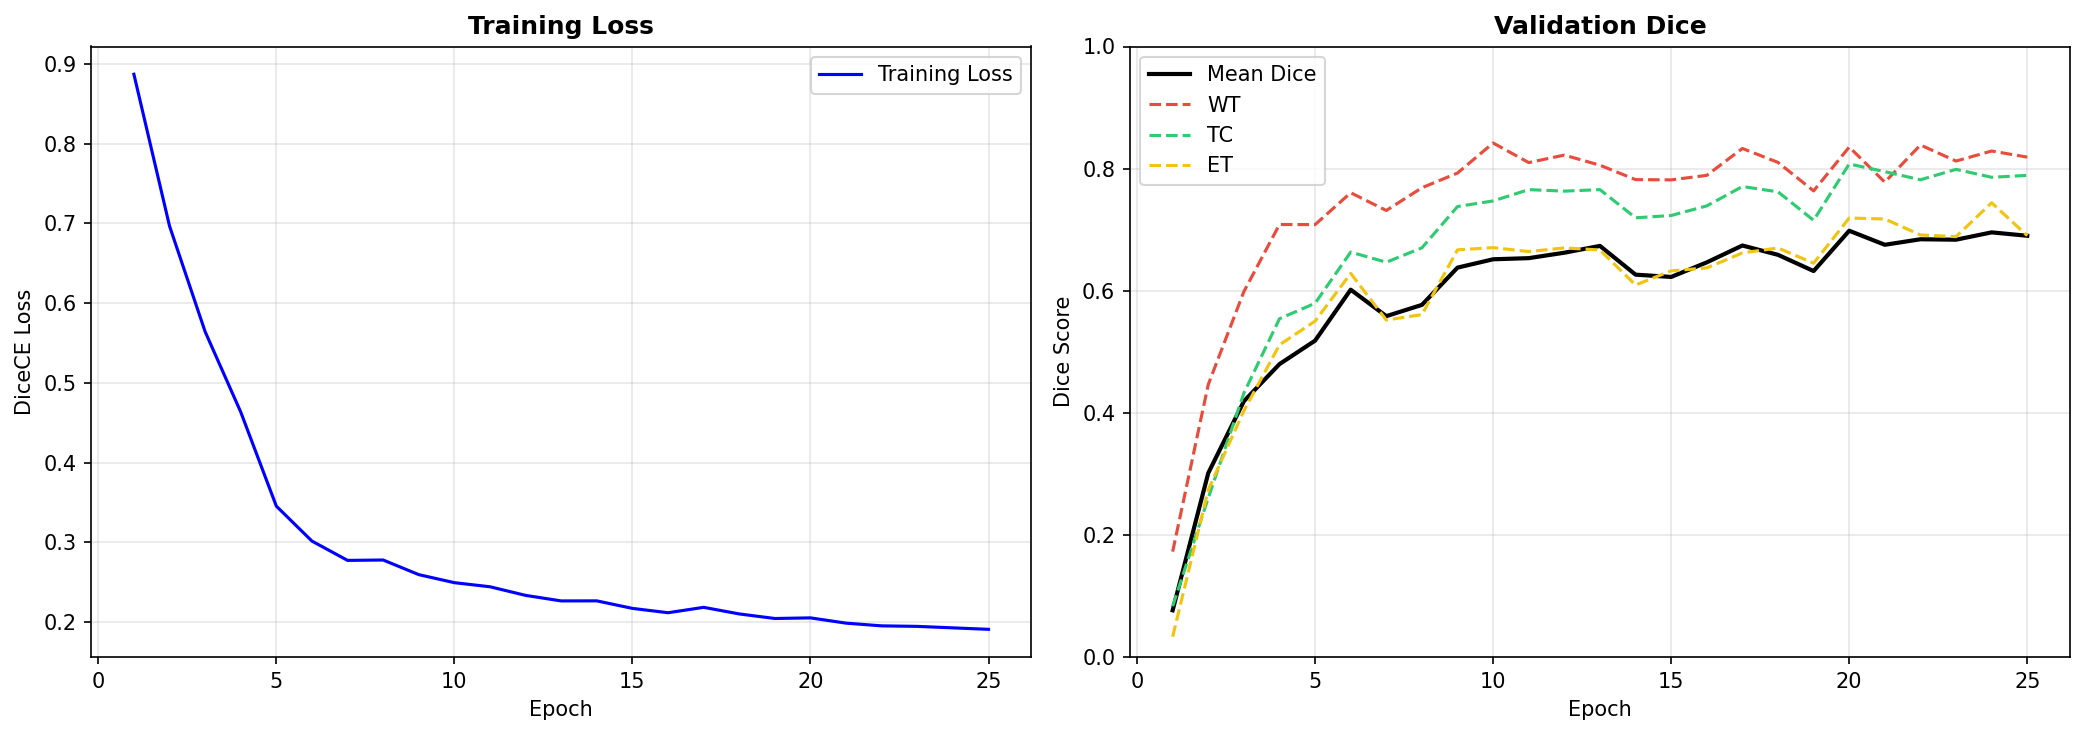

In [40]:
import gc
import time

# 1. Clear GPU and System RAM before starting
torch.cuda.empty_cache()
gc.collect()

# --- Data Setup (Optimized for Stability) ---
# Disable cache to prevent Kaggle System RAM crashes
dataset = BraTSDataset(data_dir, cache=False) 
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])

# num_workers=2 and persistent_workers=False for better reliability on T4
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Split  →  Train: {len(train_ds)}  Val: {len(val_ds)}")

# --- Model & Optimizer ---
model = MSA_ResUNet3D(dropout_p=0.1, deep_sup=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

ce_weights = torch.tensor([0.10, 1.50, 1.00, 2.50], device=device)
criterion  = DiceCELoss(ce_weight=ce_weights)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# LR scheduler
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
warmup_sched  = LinearLR(optimizer, start_factor=0.01, total_iters=5)
cosine_sched  = CosineAnnealingLR(optimizer, T_max=num_epochs - 5)
scheduler     = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[5])

# Modern AMP Scaler
scaler = torch.amp.GradScaler('cuda') 

# --- Training History & Logic ---
accumulation_steps = 4 
history = {'train_loss':[], 'val_dice':[], 'val_wt':[], 'val_tc':[], 'val_et':[], 'lr':[]}
best_val_dice = 0.0
patience, no_improve = 10, 0

print("\n" + "="*72)
print("  MSA-ResUNet3D Training (Stable Gradient Accumulation Mode)")
print("="*72)

for epoch in range(num_epochs):
    t0 = time.time()
    # ---- TRAIN PHASE ----
    model.train()
    optimizer.zero_grad(set_to_none=True)
    t_loss = t_dice = n_pat = 0
    
    for i, (images, masks) in enumerate(train_loader):
        if masks.dim() == 5: masks = masks.squeeze(1)
        images, masks = images[0], masks[0]

        for _ in range(patches_per_patient):
            ip, mp = extract_patch(images, masks, patch_size, tumor_ratio=0.7)
            ip, mp = augment_patch(ip, mp)
            ip, mp = ip.unsqueeze(0).to(device), mp.unsqueeze(0).to(device)

            with torch.amp.autocast('cuda'): # Modern AMP
                outputs = model(ip)
                if isinstance(outputs, tuple):
                    out_main, out_ds3, out_ds2 = outputs
                    mp_ds3 = F.interpolate(mp.float().unsqueeze(1), scale_factor=0.25, mode='nearest').long().squeeze(1)
                    mp_ds2 = F.interpolate(mp.float().unsqueeze(1), scale_factor=0.5,  mode='nearest').long().squeeze(1)
                    loss = (criterion(out_main, mp) + 0.3*criterion(out_ds3, mp_ds3) + 0.3*criterion(out_ds2, mp_ds2))
                else:
                    out_main = outputs
                    loss = criterion(out_main, mp)
                
                loss = loss / (accumulation_steps * patches_per_patient)

            scaler.scale(loss).backward()
            with torch.no_grad():
                t_dice += dice_score(out_main, mp)
            t_loss += loss.item()

        if (i + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        n_pat += 1

    scheduler.step()

    # ---- VALIDATION PHASE ----
    model.eval()
    v_dice = v_wt = v_tc = v_et = n_val = 0
    with torch.no_grad():
        for images, masks in val_loader:
            if masks.dim() == 5: masks = masks.squeeze(1)
            images, masks = images[0], masks[0]
            # Validate on 2 patches per patient for speed
            for _ in range(2):
                ip, mp = extract_patch(images, masks, patch_size, tumor_ratio=0.7)
                ip, mp = ip.unsqueeze(0).to(device), mp.unsqueeze(0).to(device)
                with torch.amp.autocast('cuda'):
                    out = model(ip)
                if isinstance(out, tuple): out = out[0]
                v_dice += dice_score(out, mp)
                wt, tc, et = brats_dice(out, mp)
                v_wt += wt; v_tc += tc; v_et += et
                n_val += 1

    # Average metrics
    avg_vd = (v_dice / n_val).item() if hasattr(v_dice,'item') else v_dice/n_val
    avg_wt, avg_tc, avg_et = v_wt/n_val, v_tc/n_val, v_et/n_val
    cur_lr = scheduler.get_last_lr()[0]
    epoch_time = time.time() - t0

    history['train_loss'].append(t_loss/n_pat)
    history['val_dice'].append(avg_vd)
    history['val_wt'].append(avg_wt)
    history['val_tc'].append(avg_tc)
    history['val_et'].append(avg_et)
    history['lr'].append(cur_lr)

    print(f"[{epoch+1:03d}/{num_epochs}] {epoch_time:.0f}s | LR {cur_lr:.2e} | "
          f"Loss {t_loss/n_pat:.4f} | ValDice {avg_vd:.4f} | "
          f"WT {avg_wt:.4f} TC {avg_tc:.4f} ET {avg_et:.4f}")

    # Checkpoint Saving
    if avg_vd > best_val_dice:
        best_val_dice = avg_vd
        no_improve = 0
        raw_model = model.module if hasattr(model, 'module') else model
        torch.save({
            'epoch': epoch,
            'model_state_dict': raw_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_dice': best_val_dice,
            'history': history,
        }, save_path)
        print(f"    ✓ Saved best checkpoint (Val Dice {best_val_dice:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"    ✗ Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining complete. Best Val Dice: {best_val_dice:.4f}")
plot_training_curves(history) # Cell 6

In [45]:
raw_model = MSA_ResUNet3D(dropout_p=0.1, deep_sup=True).to(device)
ckpt = torch.load(save_path, map_location=device)
raw_model.load_state_dict(ckpt['model_state_dict'])
raw_model.eval()
print(f"Loaded best model from {save_path} (epoch {ckpt['epoch']+1}, Dice {ckpt['best_val_dice']:.4f})")

  
  
  

Loaded best model from /kaggle/working/MSA_ResUNet3D_best.pth (epoch 20, Dice 0.6983)



  Patient 1
Running full-volume inference on sample 0...

  Full-Volume BraTS Metrics
  Region     Dice     HD95
  ────────────────────────
  WT       0.8445     5.10
  TC       0.8148     2.24
  ET       0.8176     1.73
  Avg      0.8257

[Figure 1] Publication Panel (A-E)


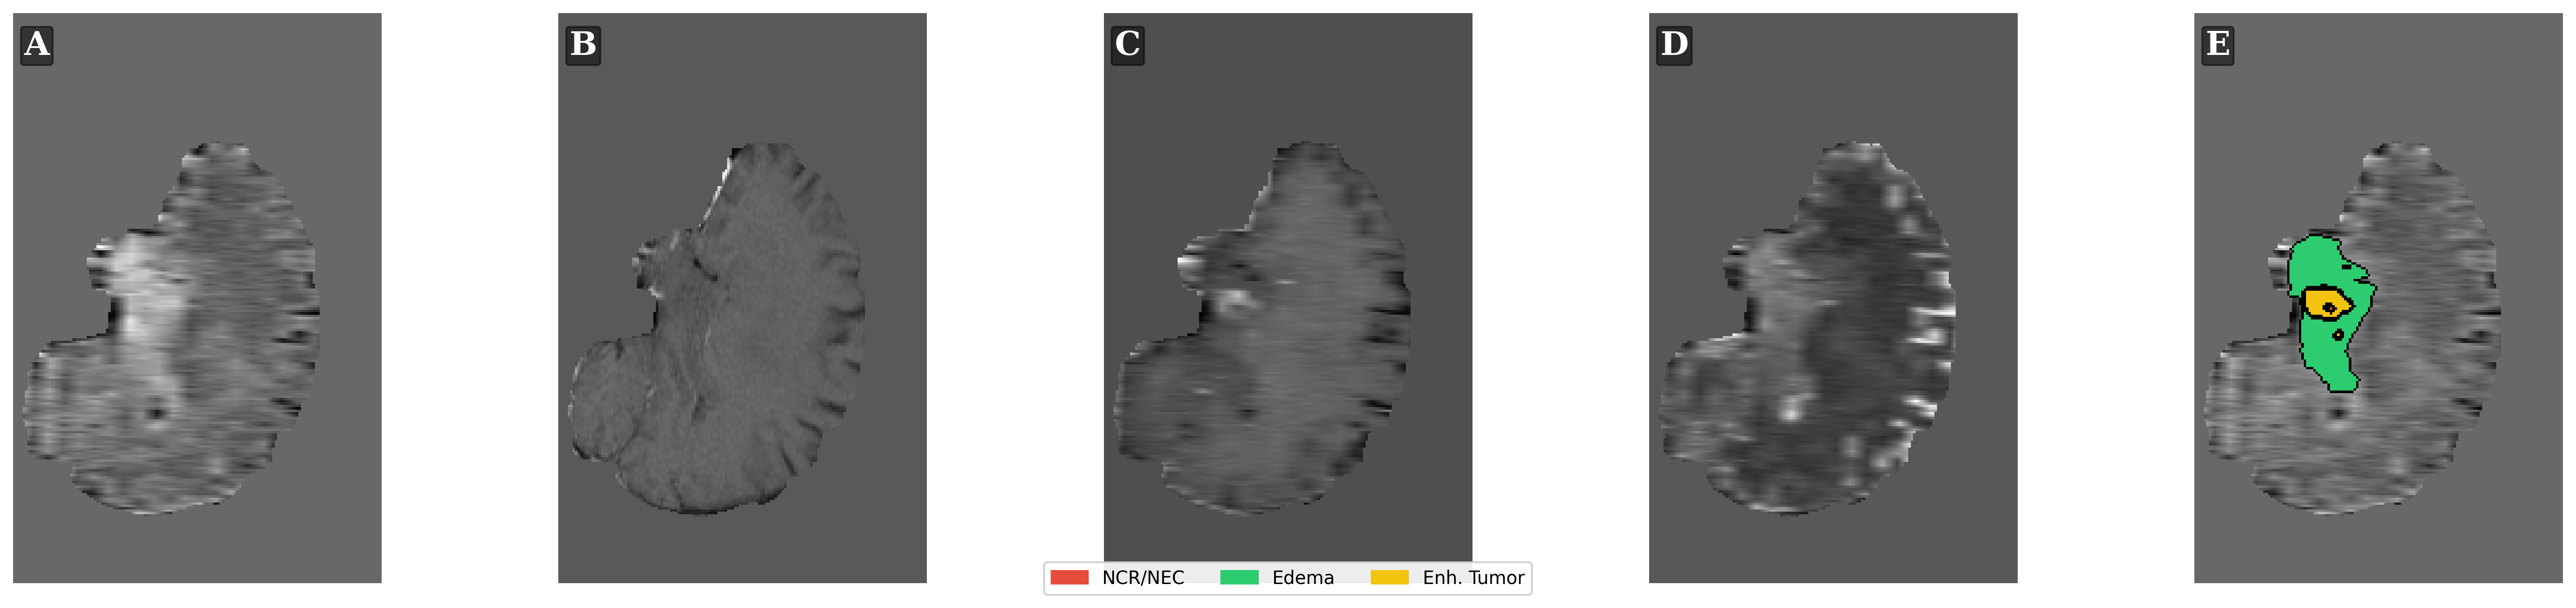

  Tumor-peak slice: z=145
[Figure 2] Main Comparison (+ Uncertainty Map)


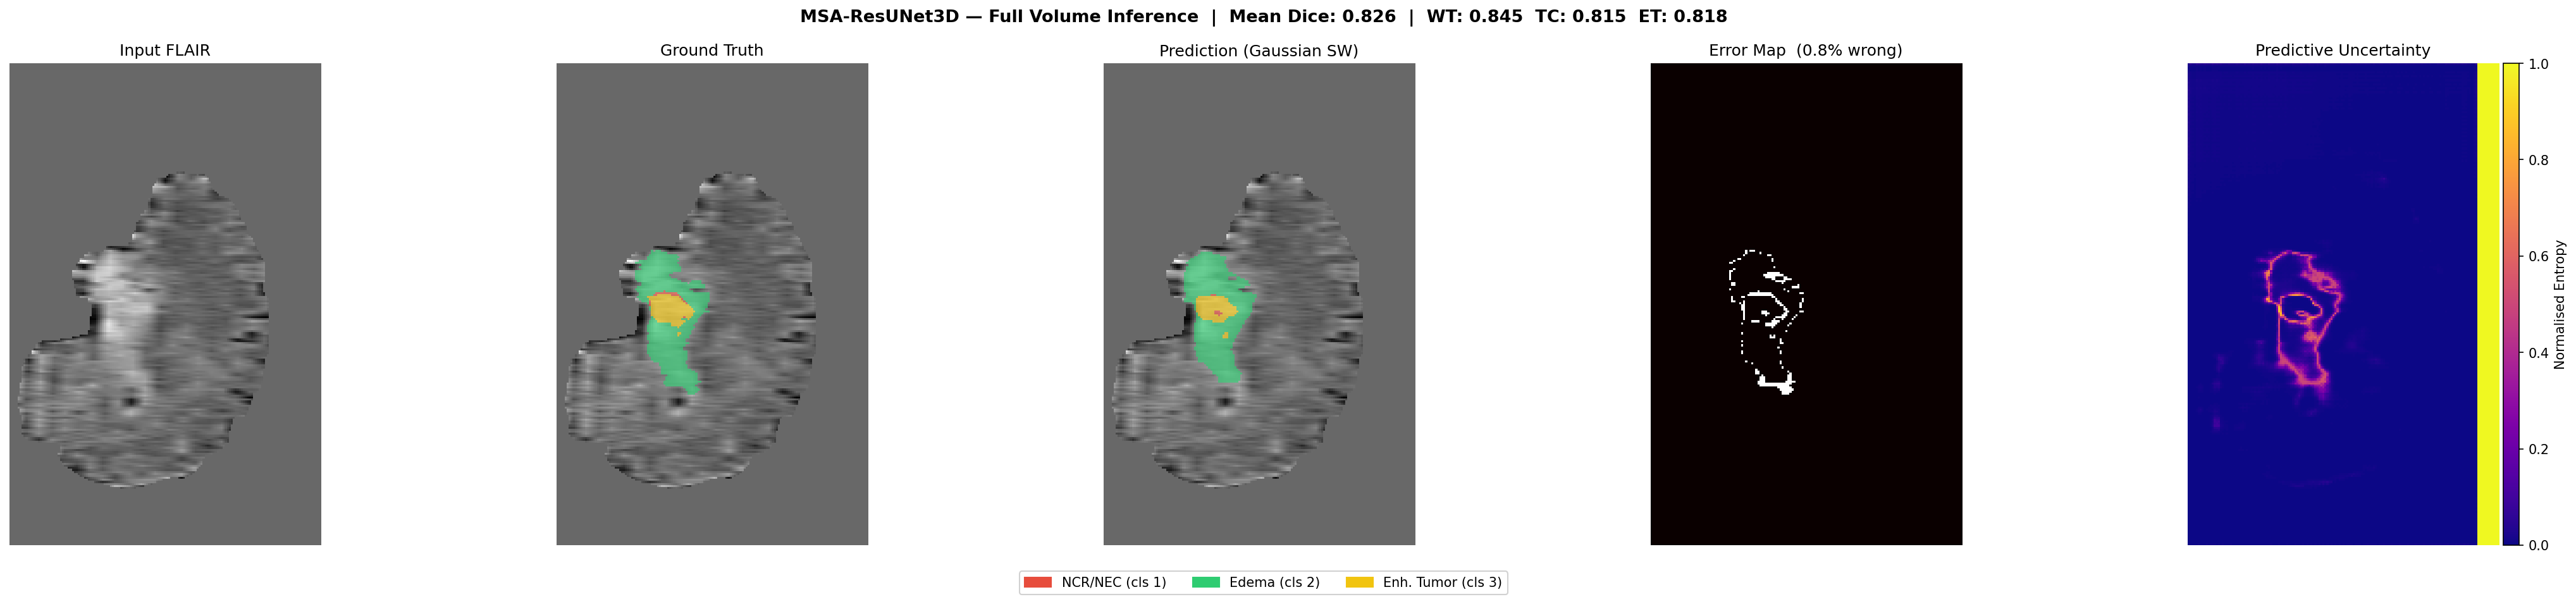

[Figure 3] BraTS Region Breakdown


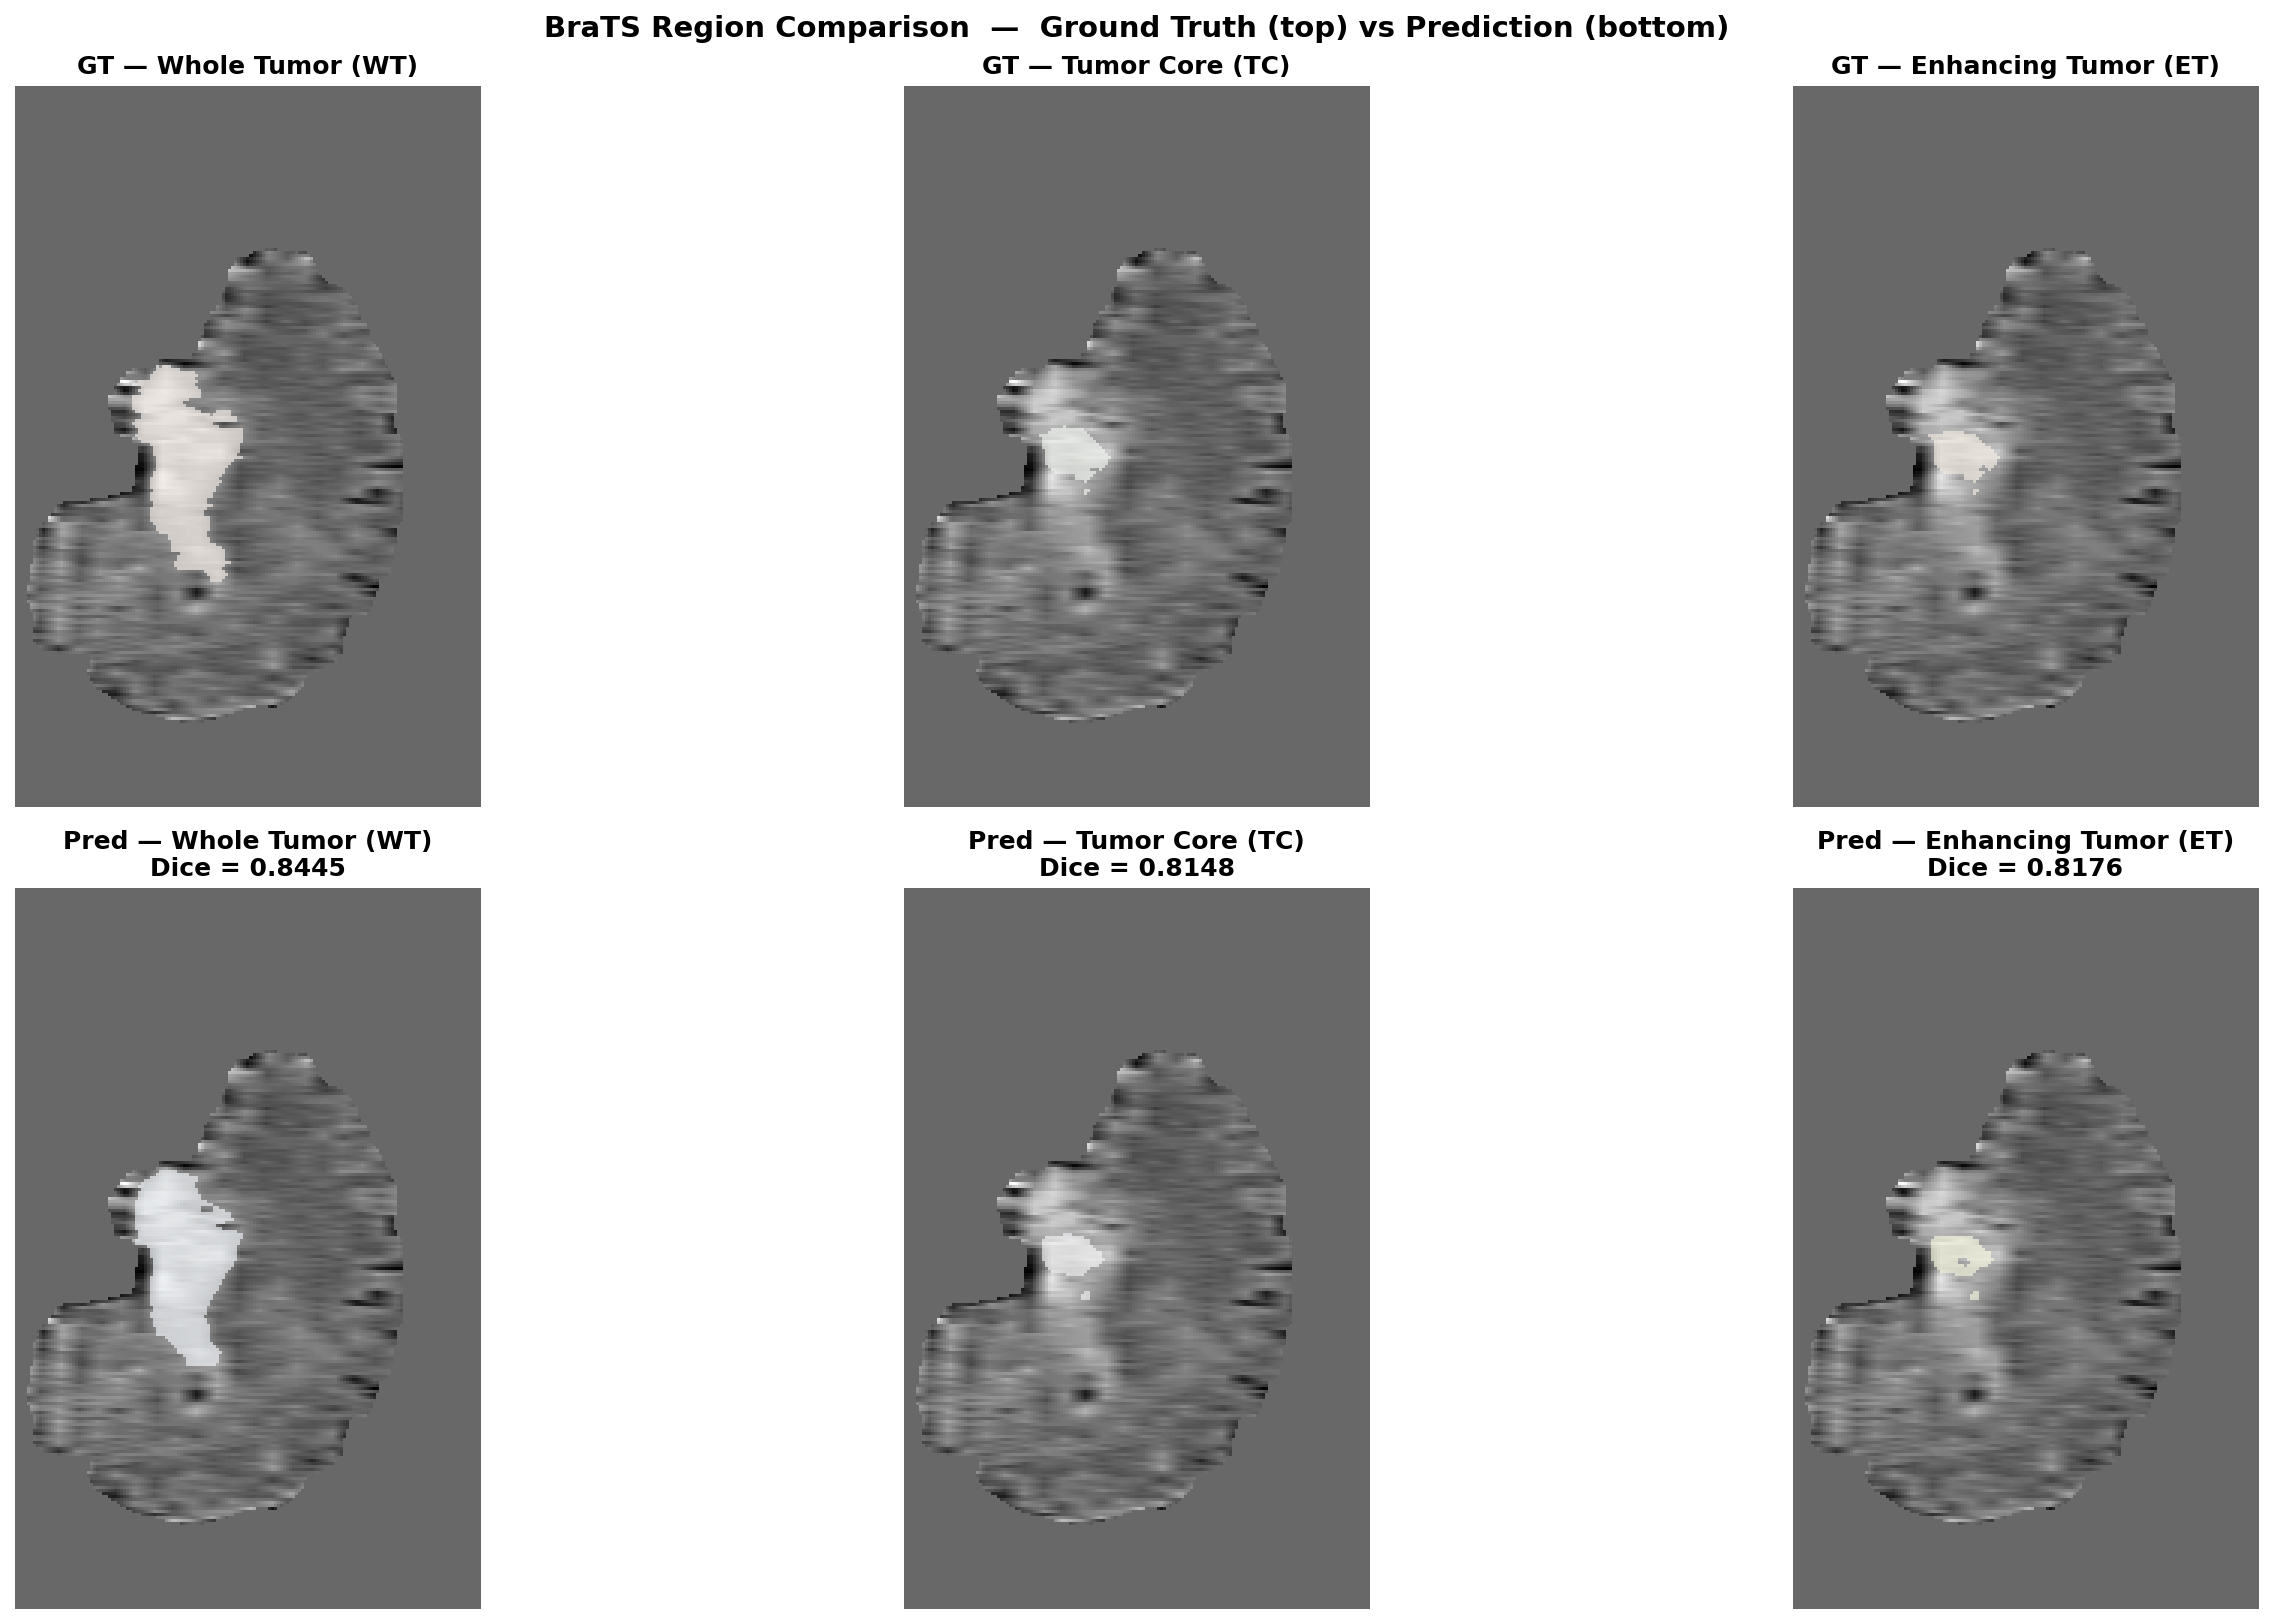

[Figure 4] Multi-Slice Spatial Consistency


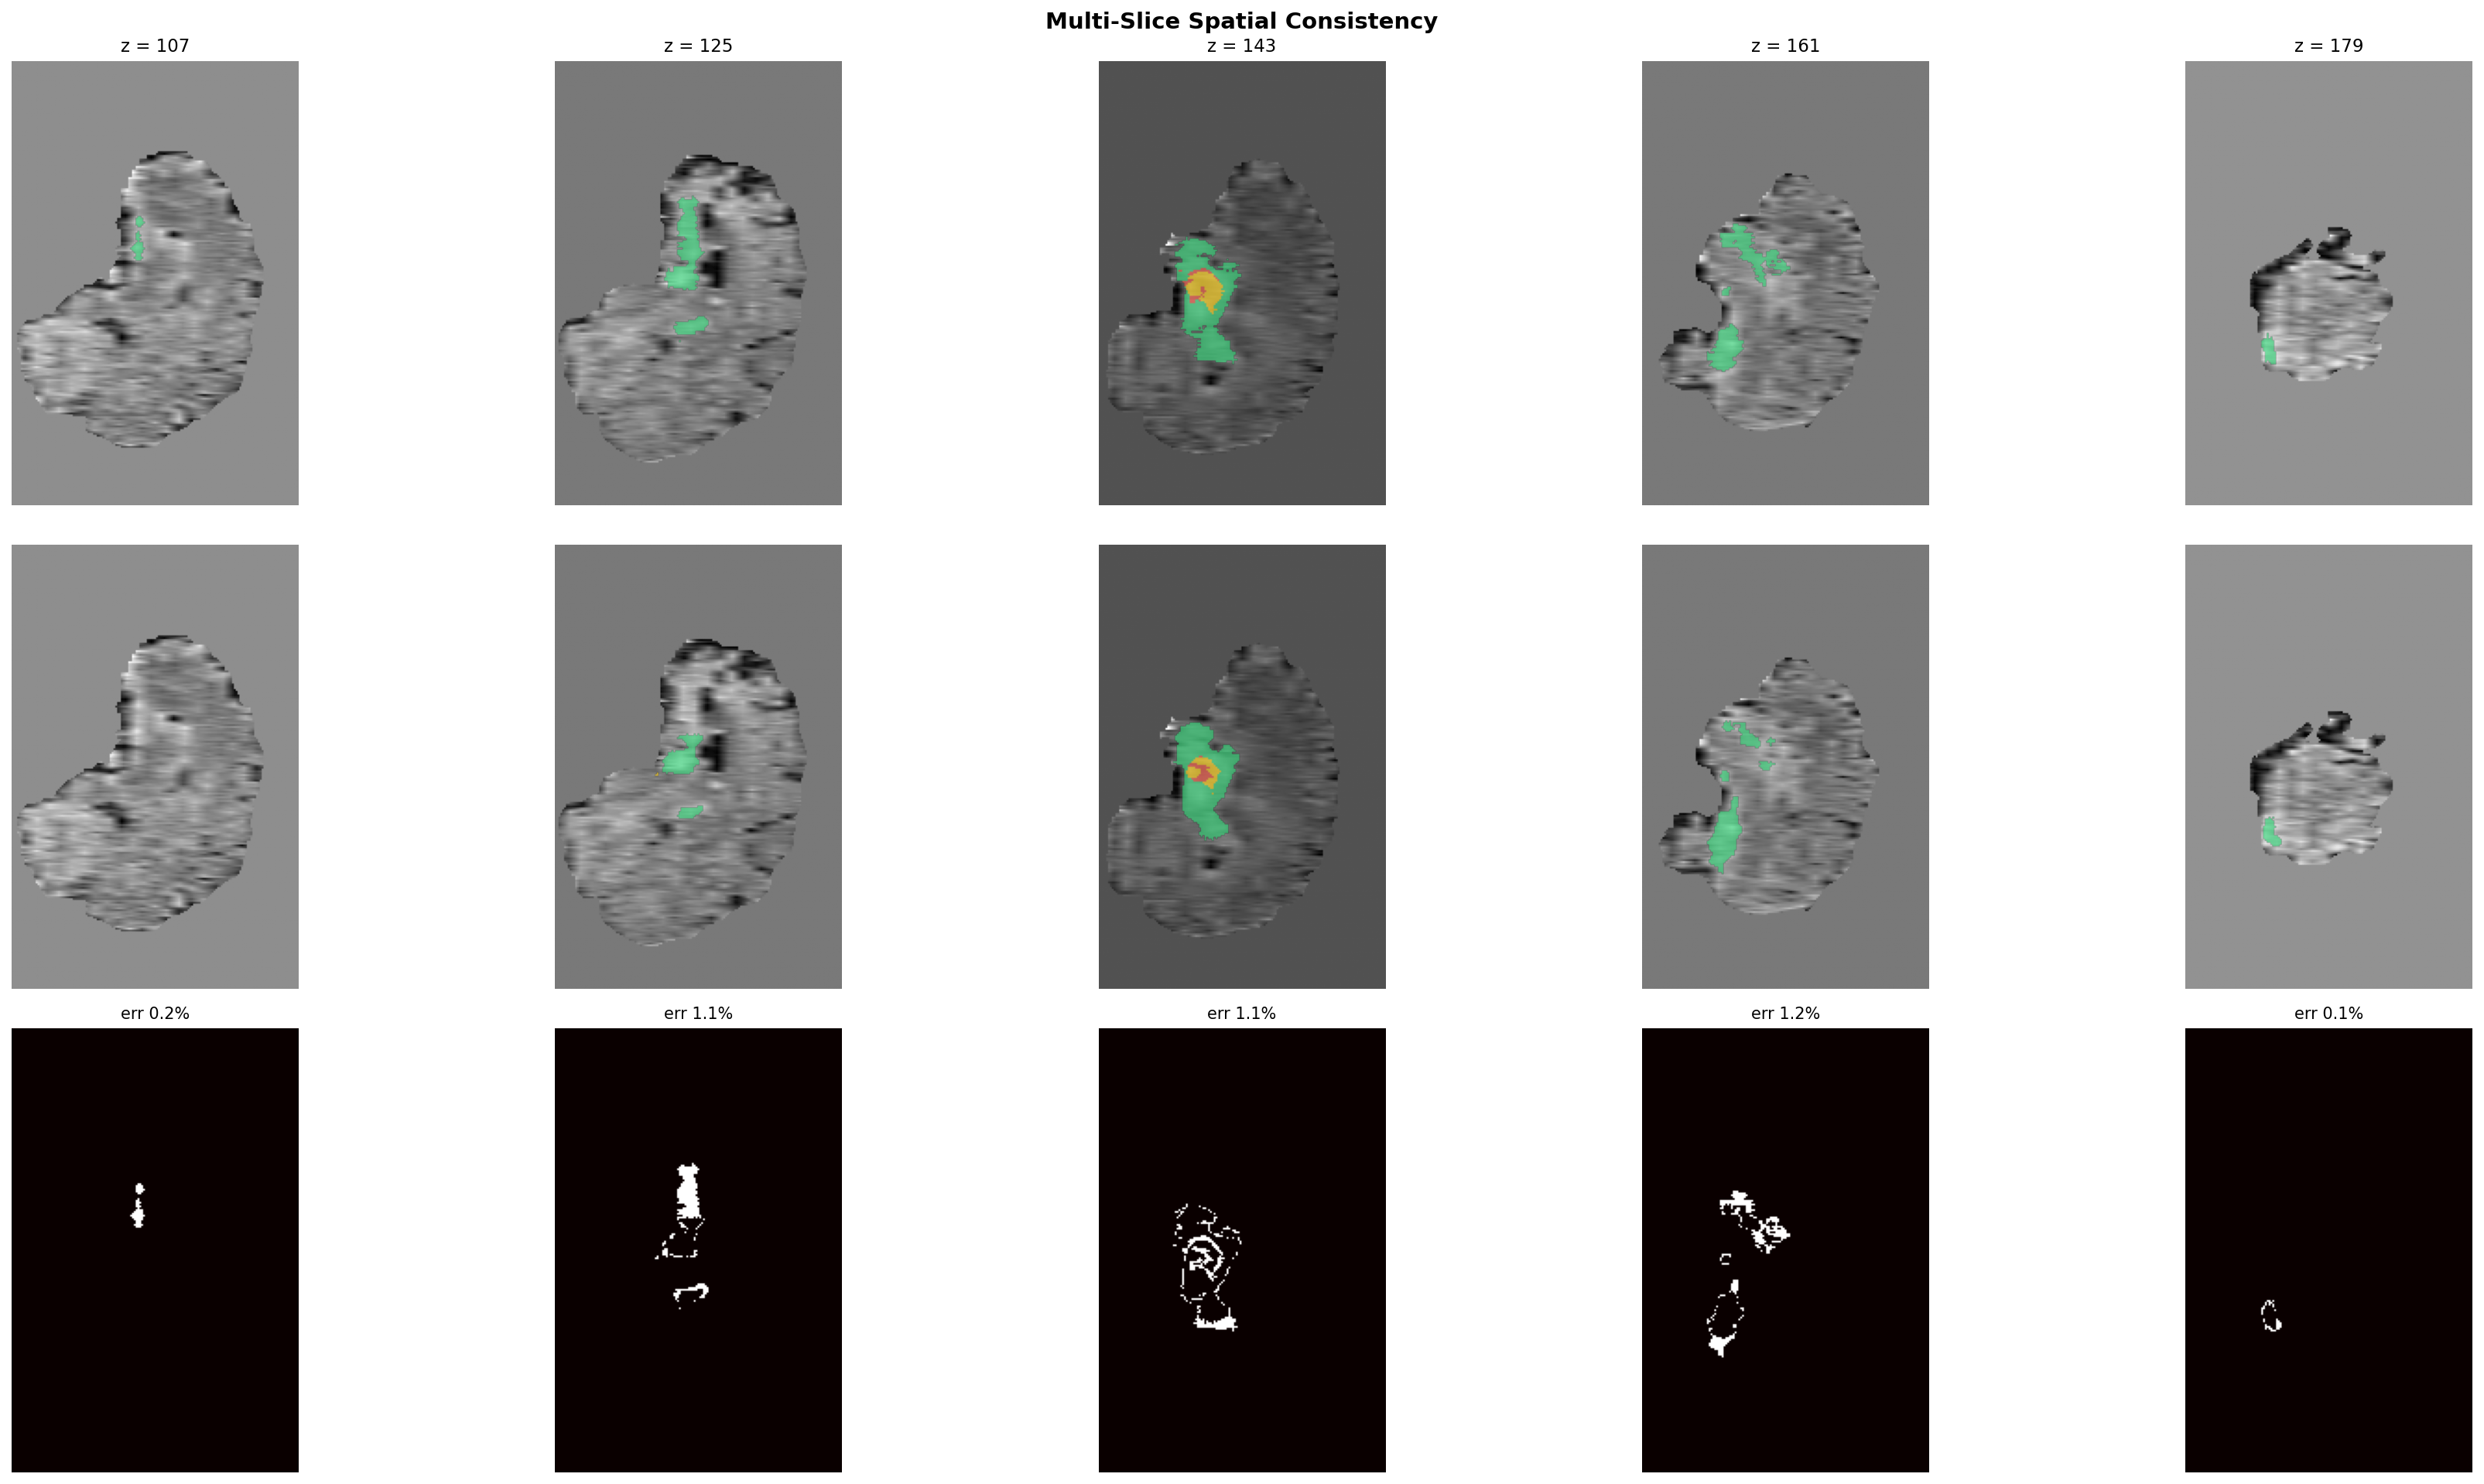

[Figure 5] Tumor Volume Statistics


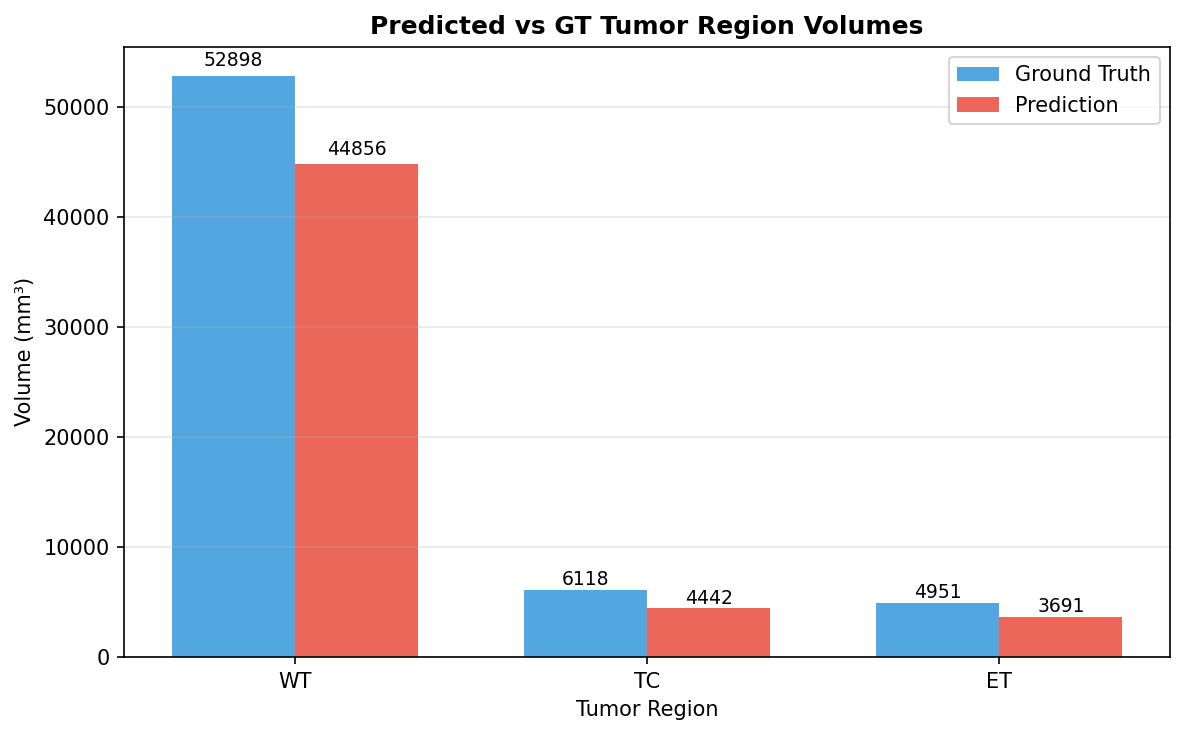


  Patient 2
Running full-volume inference on sample 1...

  Full-Volume BraTS Metrics
  Region     Dice     HD95
  ────────────────────────
  WT       0.4935    64.83
  TC       0.0087    15.78
  ET       0.0000      nan
  Avg      0.1674

[Figure 1] Publication Panel (A-E)


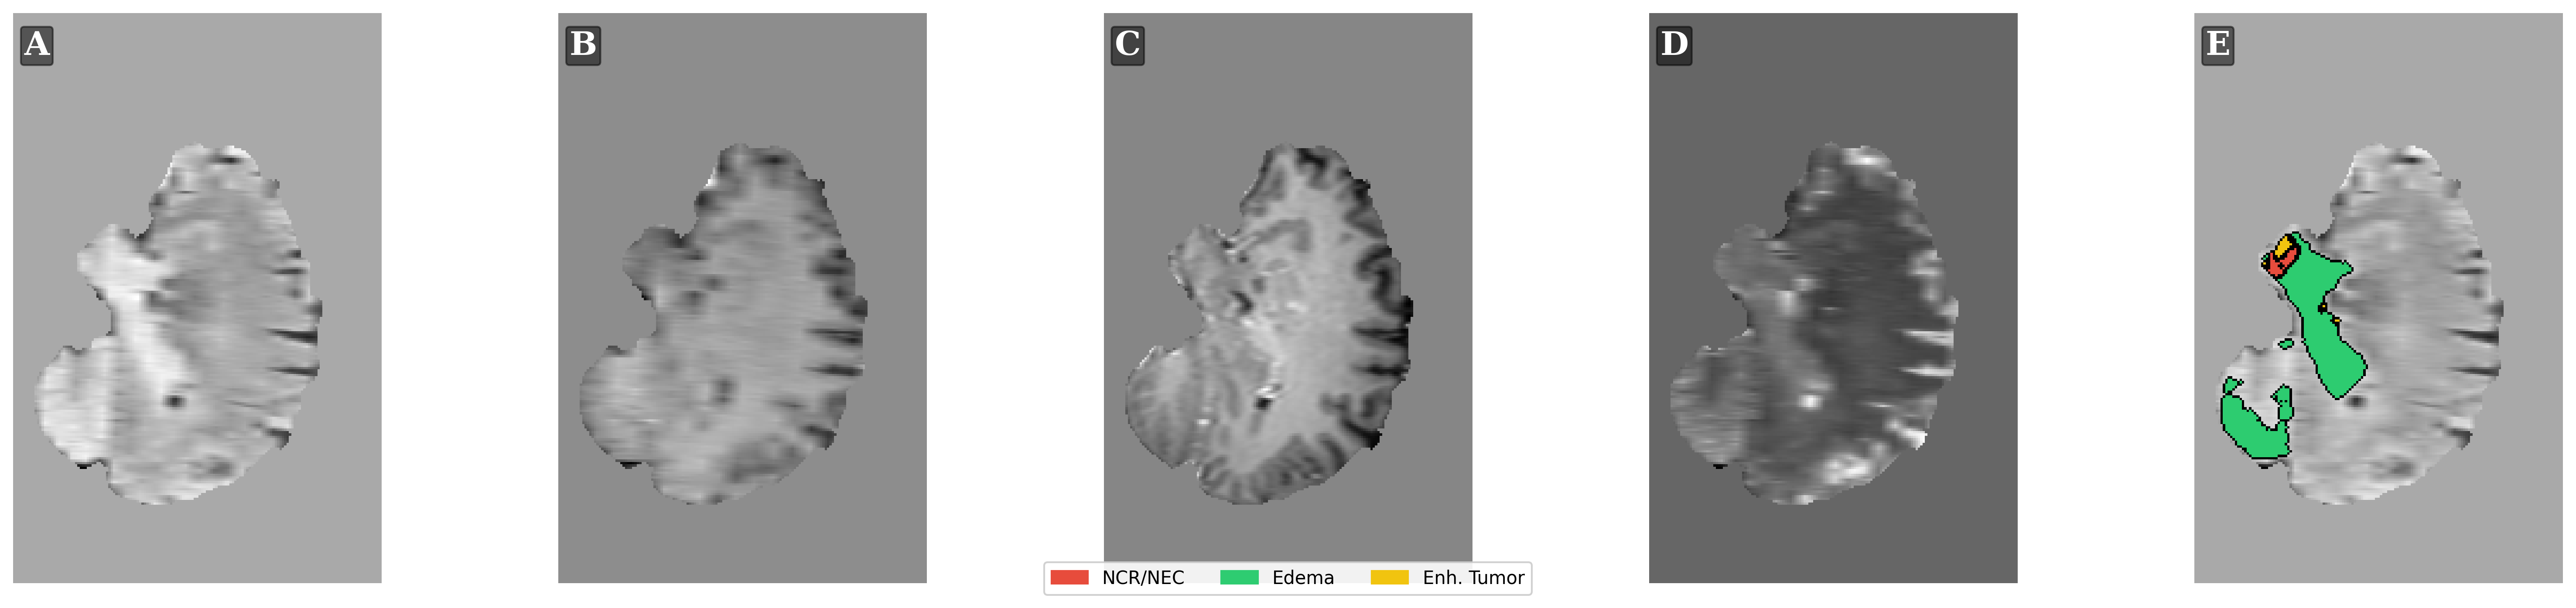

  Tumor-peak slice: z=145
[Figure 2] Main Comparison (+ Uncertainty Map)


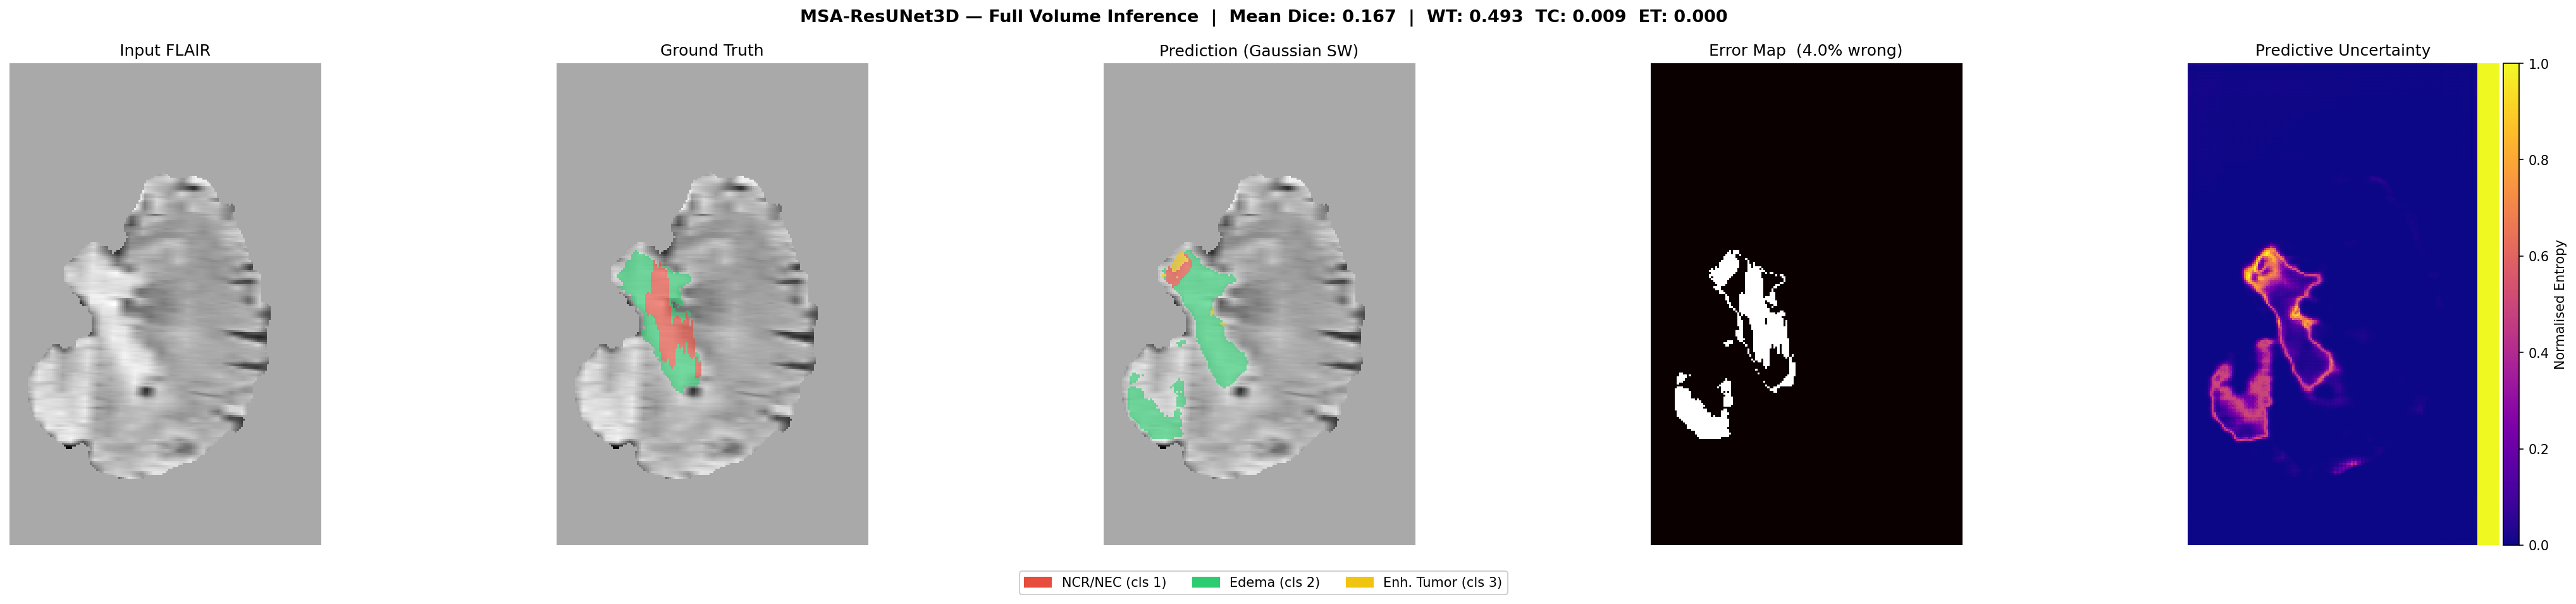

[Figure 3] BraTS Region Breakdown


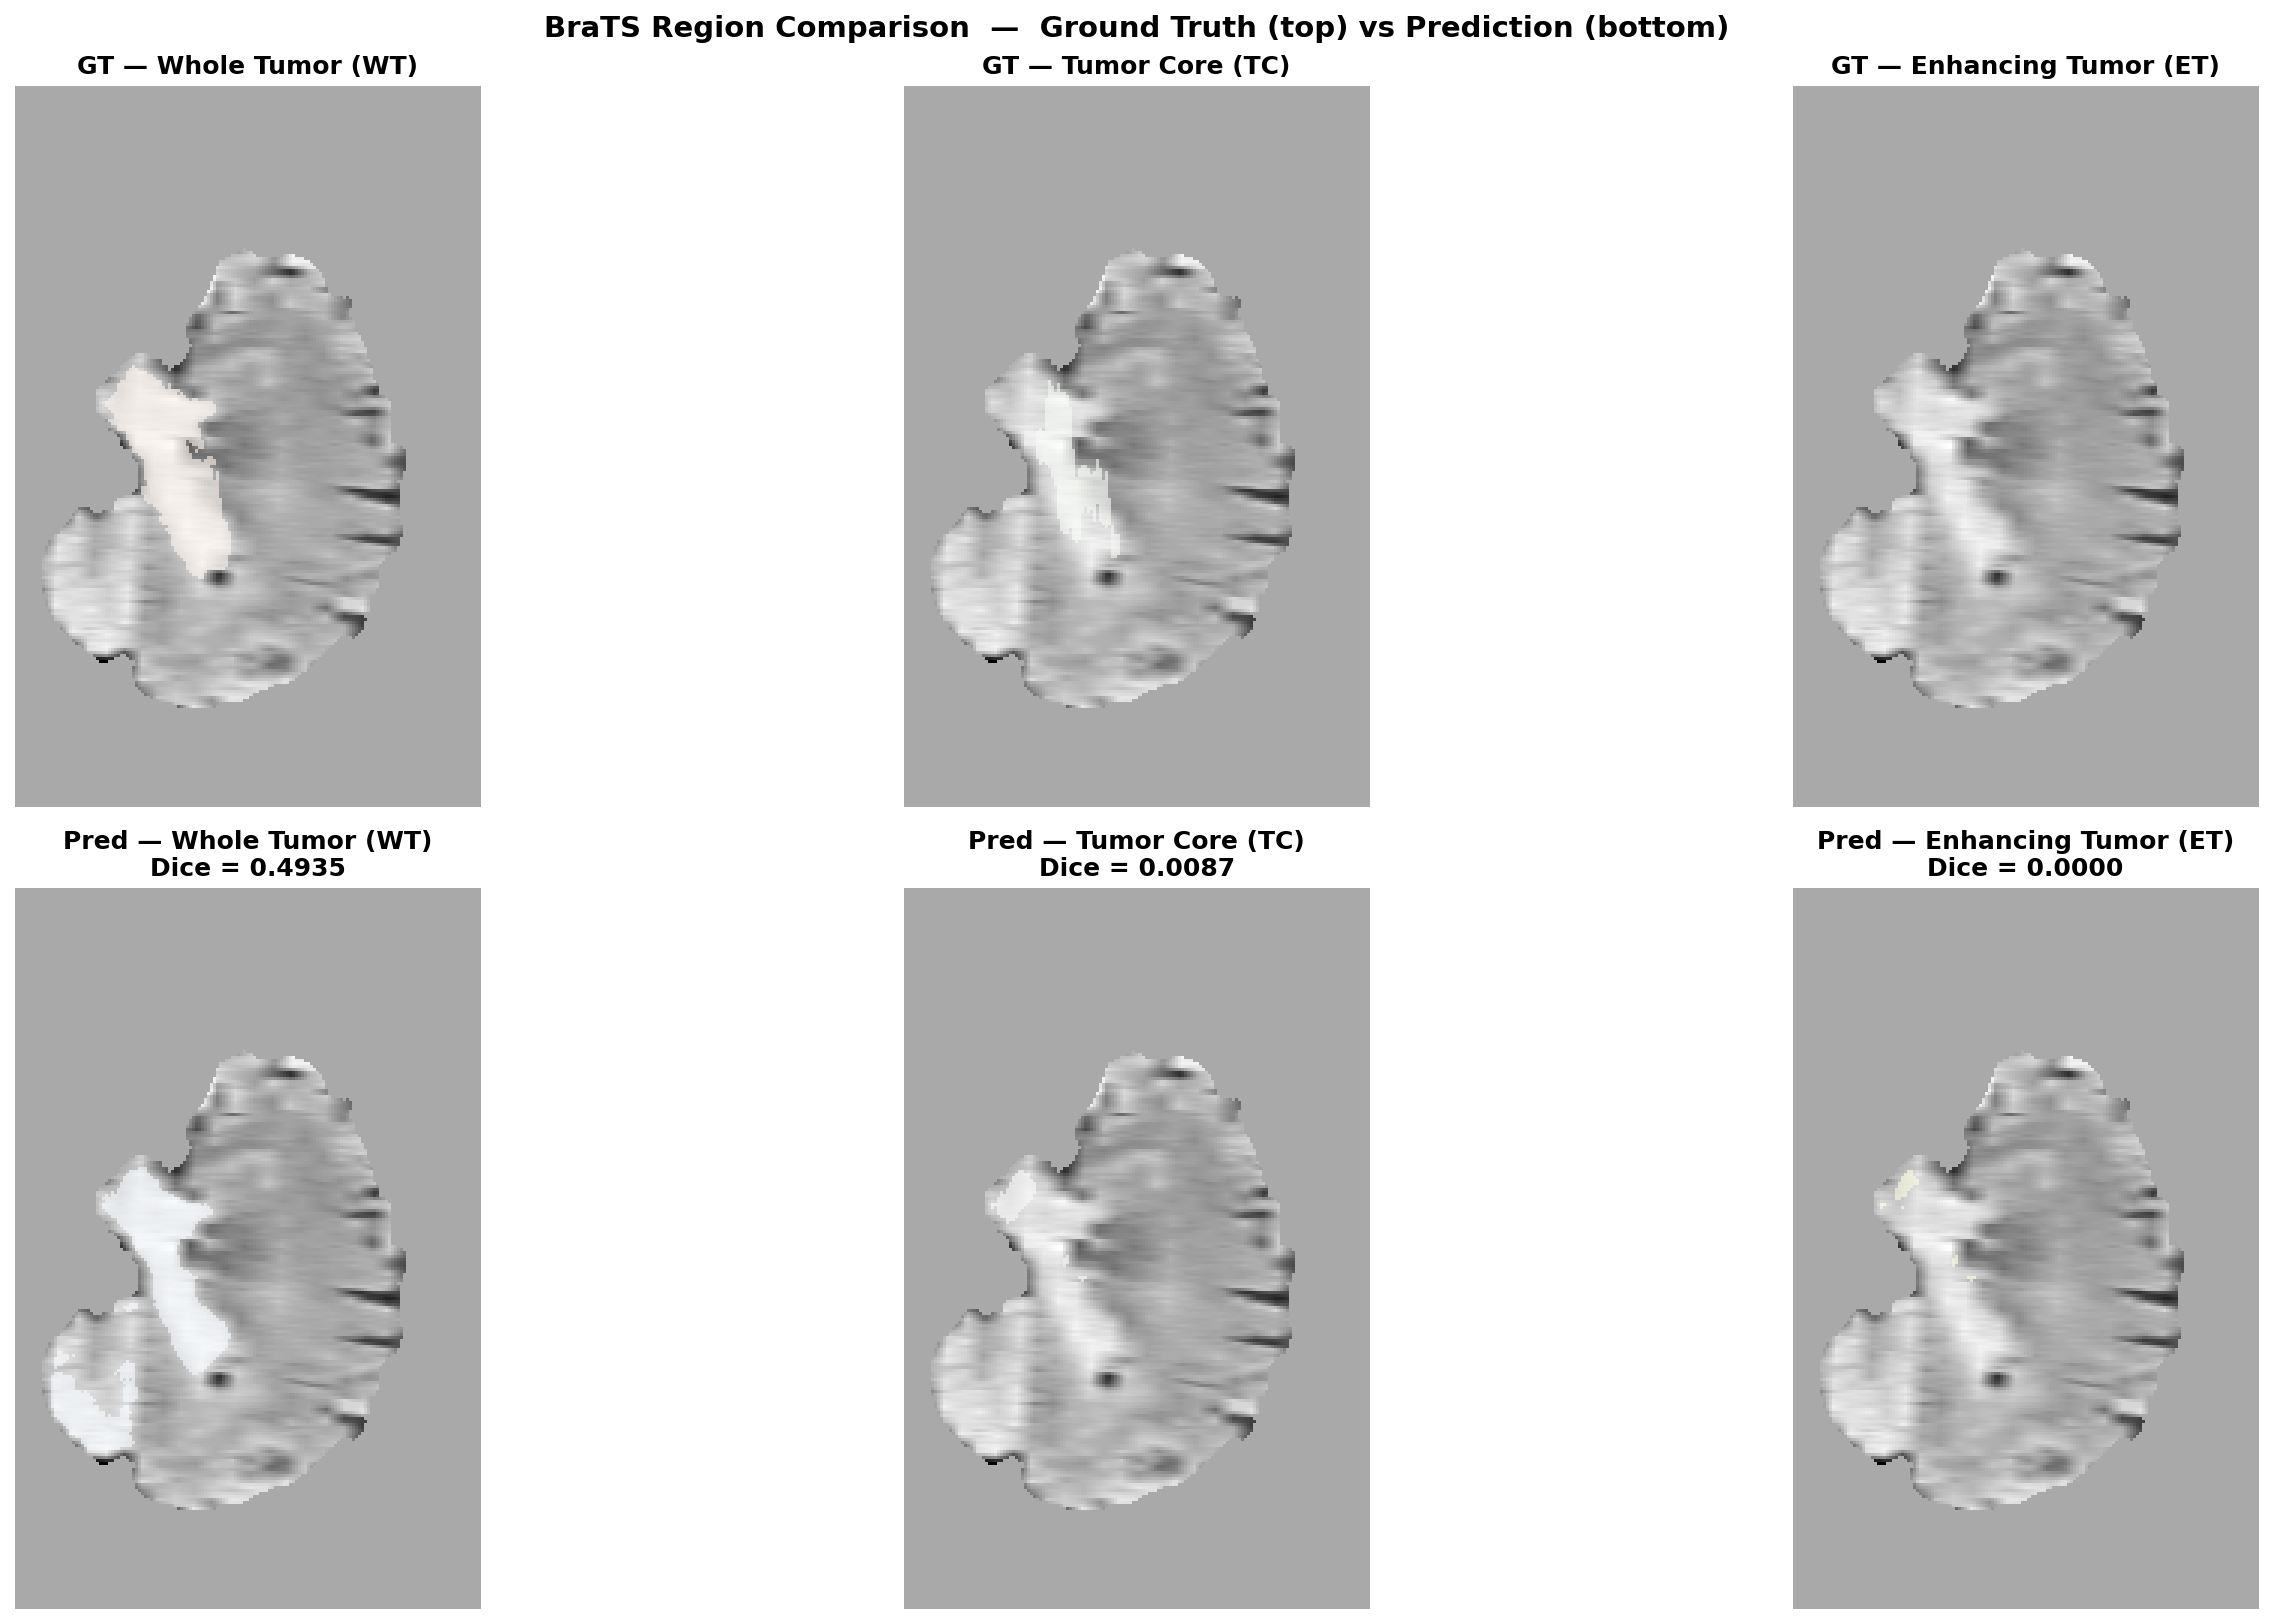

[Figure 4] Multi-Slice Spatial Consistency


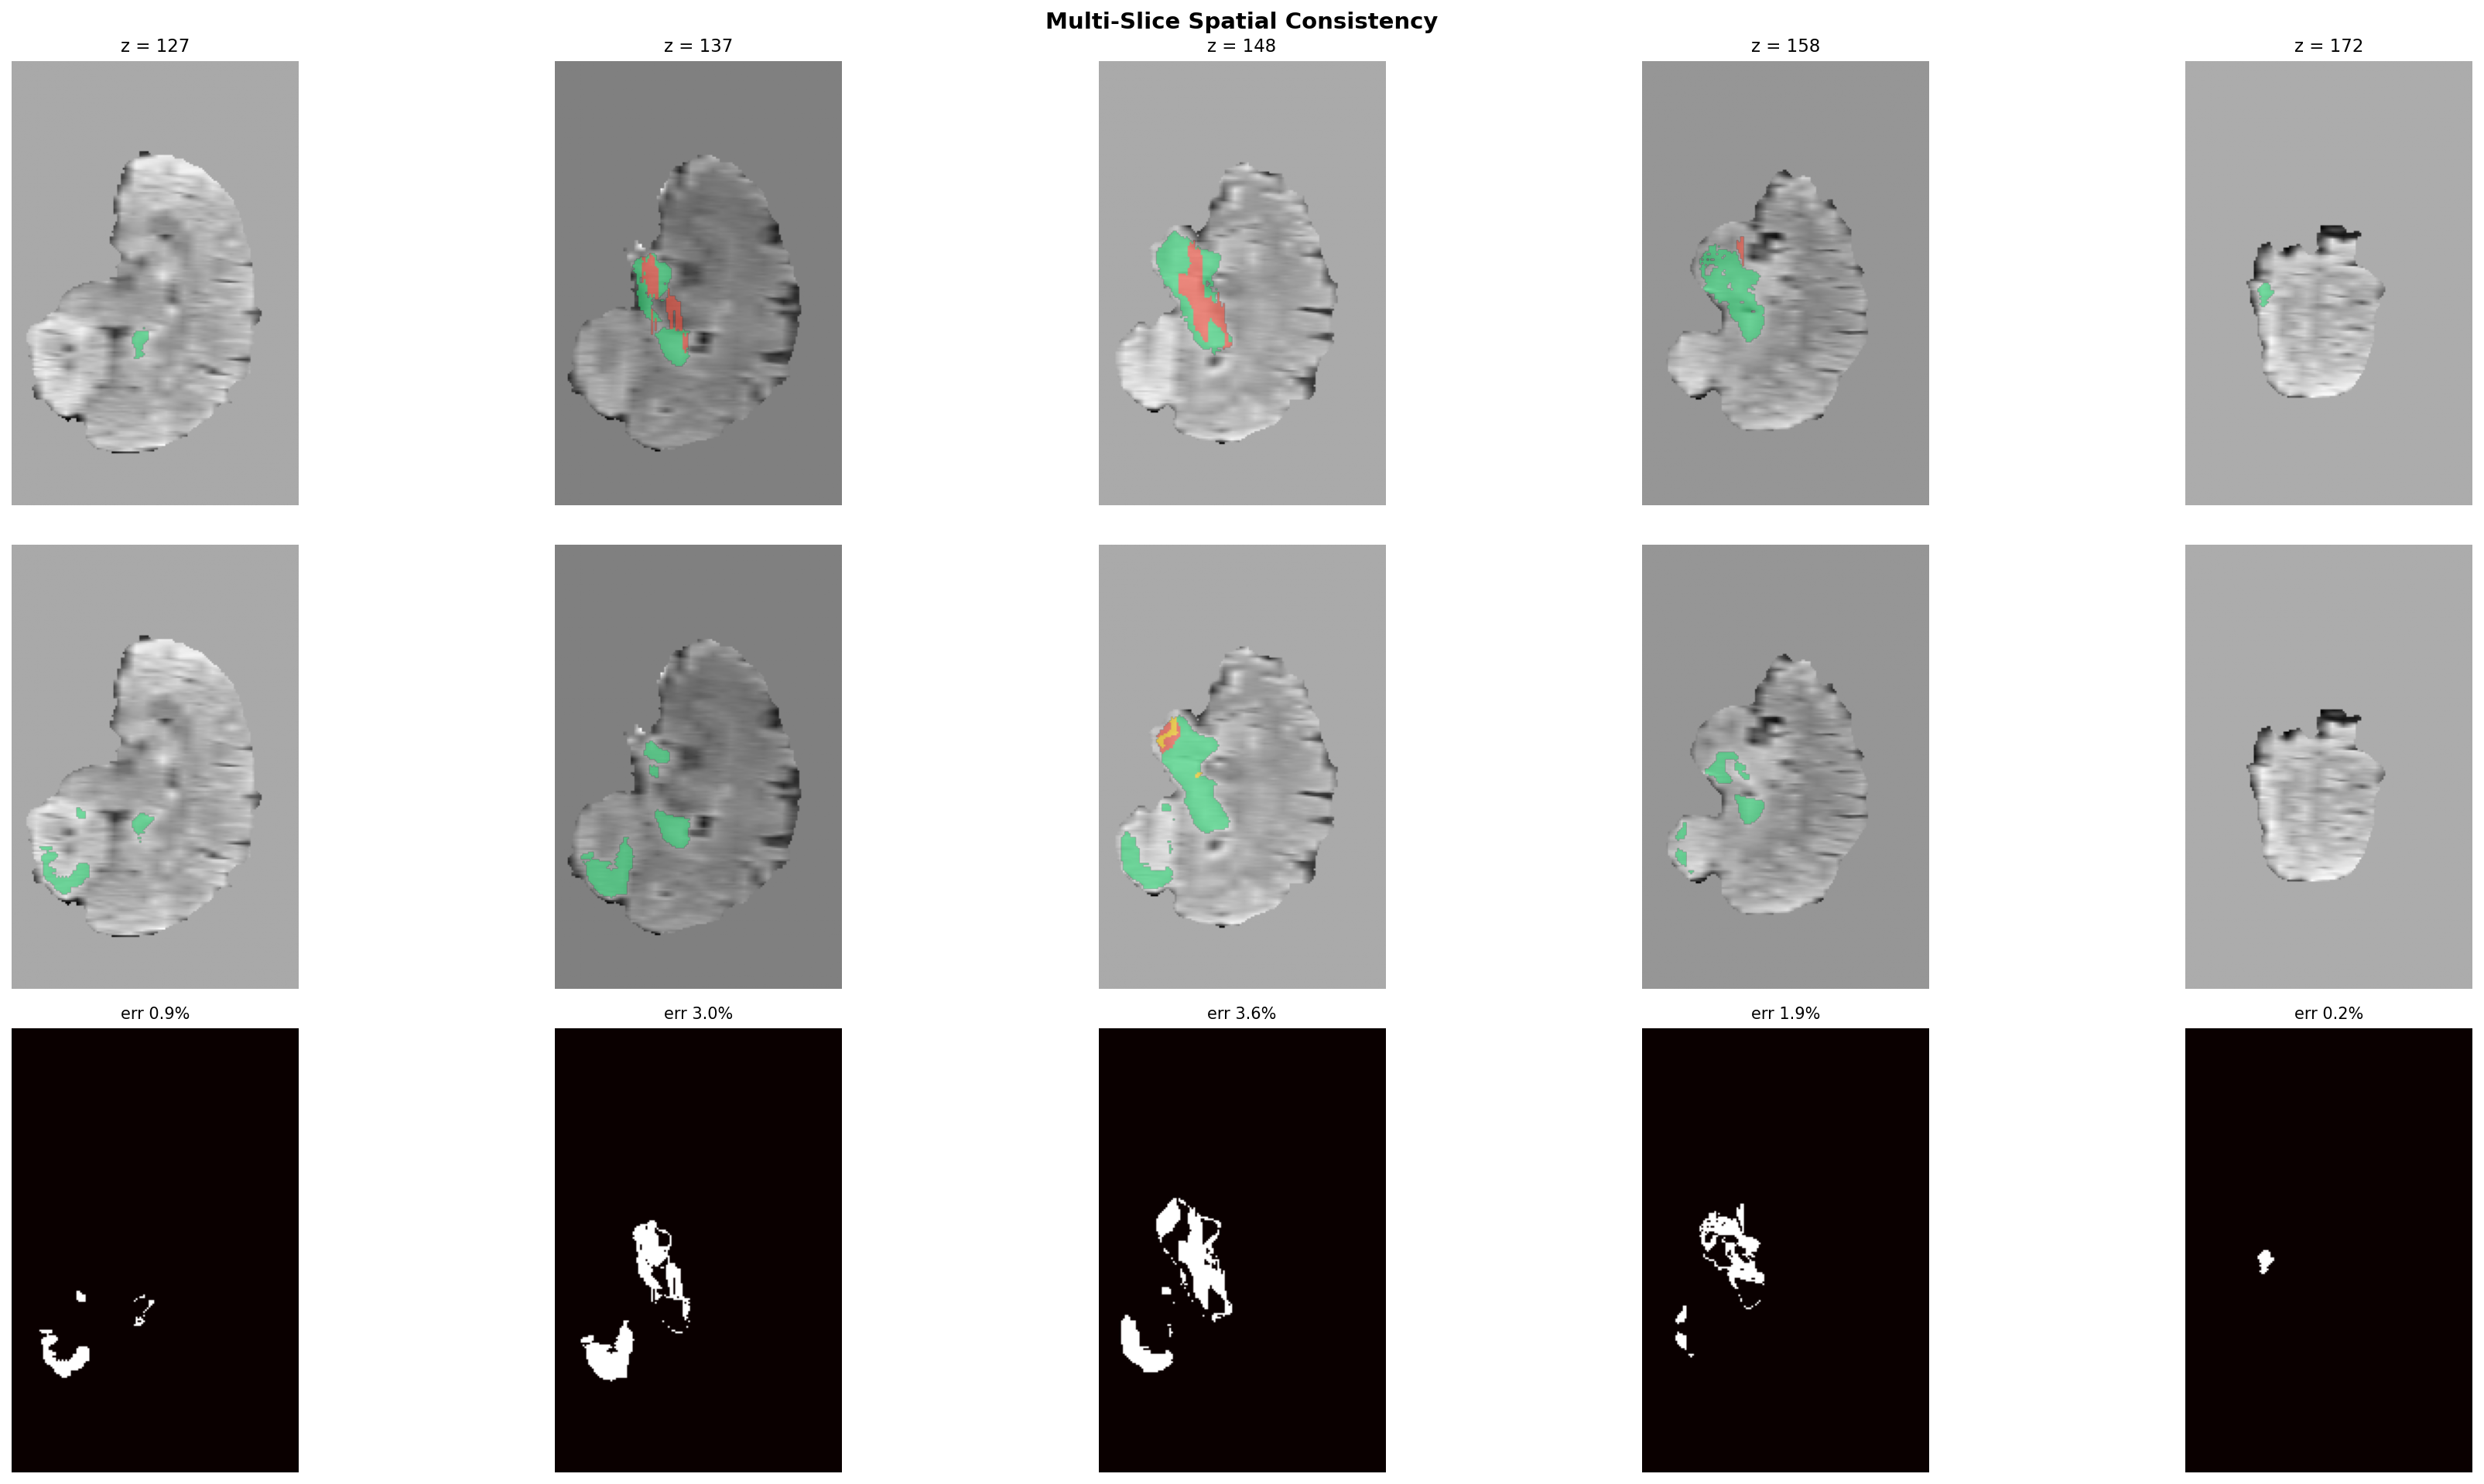

[Figure 5] Tumor Volume Statistics


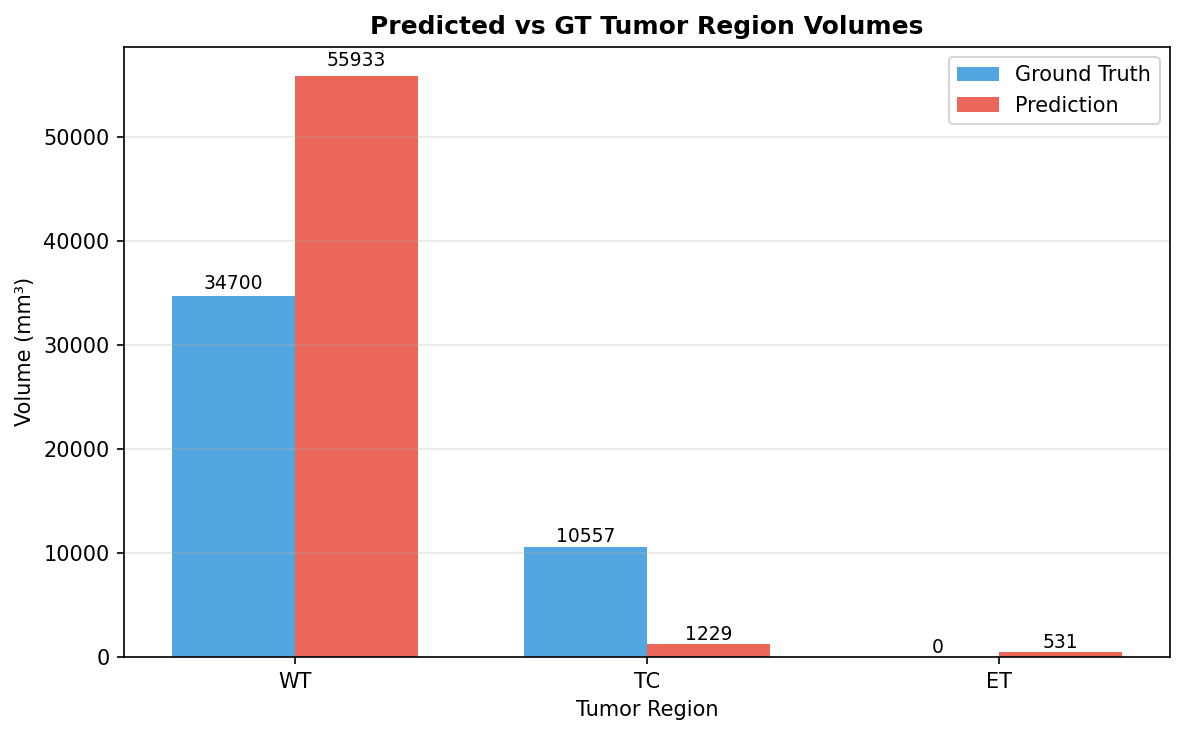


  Patient 3
Running full-volume inference on sample 2...

  Full-Volume BraTS Metrics
  Region     Dice     HD95
  ────────────────────────
  WT       0.8457    57.28
  TC       0.8590     3.61
  ET       0.0000      nan
  Avg      0.5682

[Figure 1] Publication Panel (A-E)


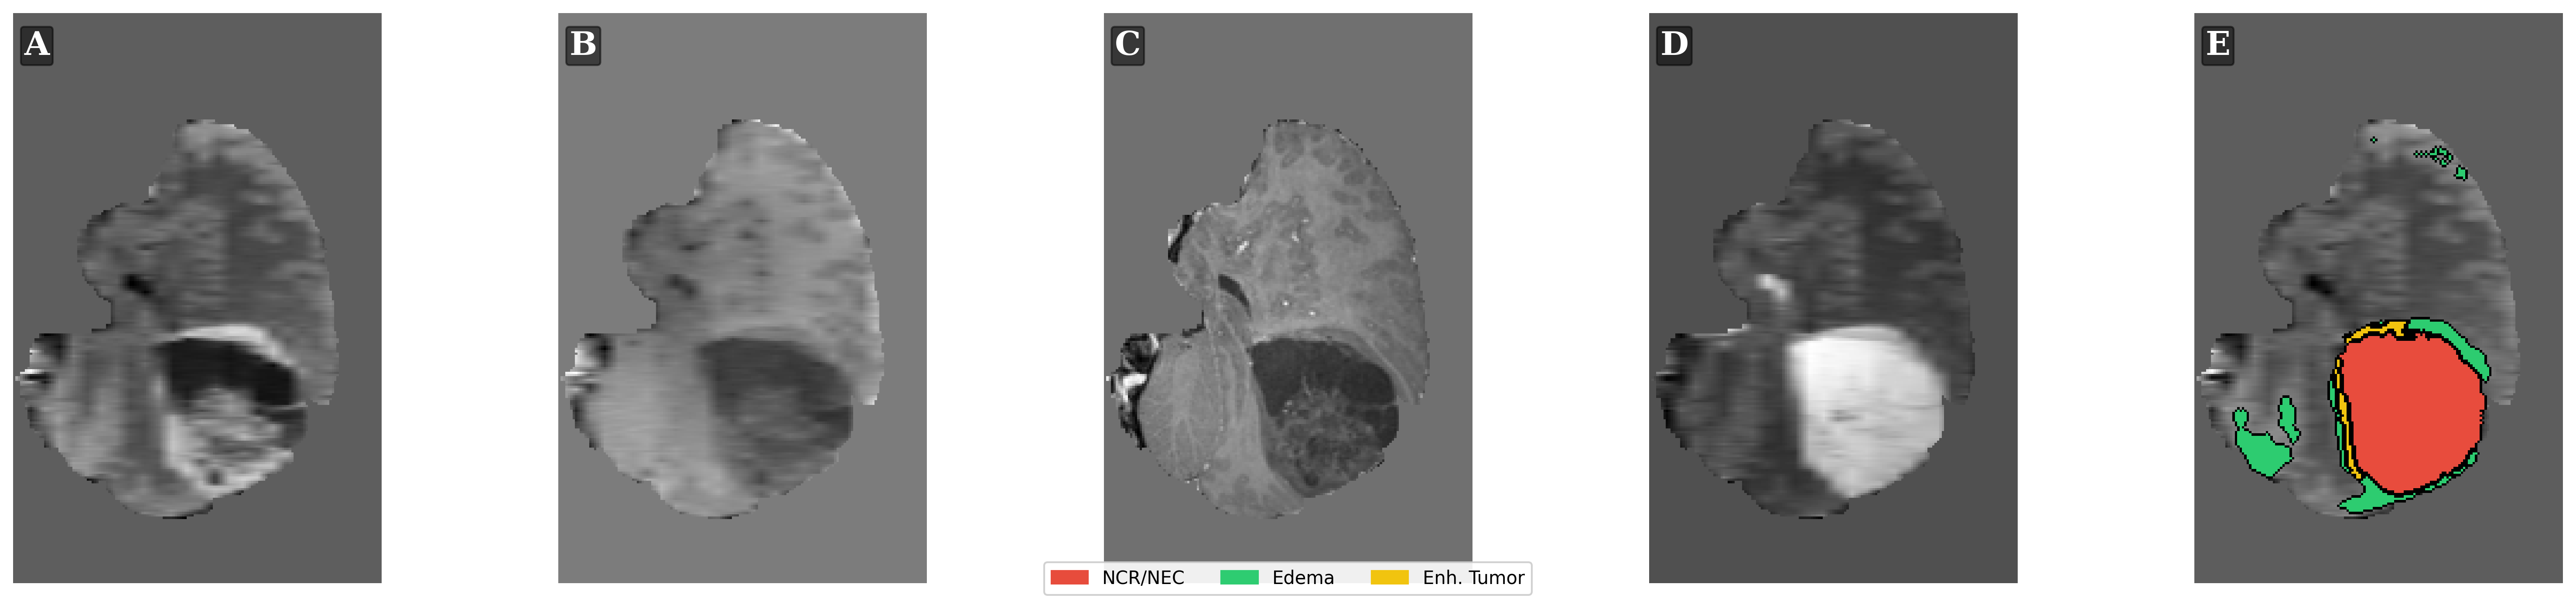

  Tumor-peak slice: z=91
[Figure 2] Main Comparison (+ Uncertainty Map)


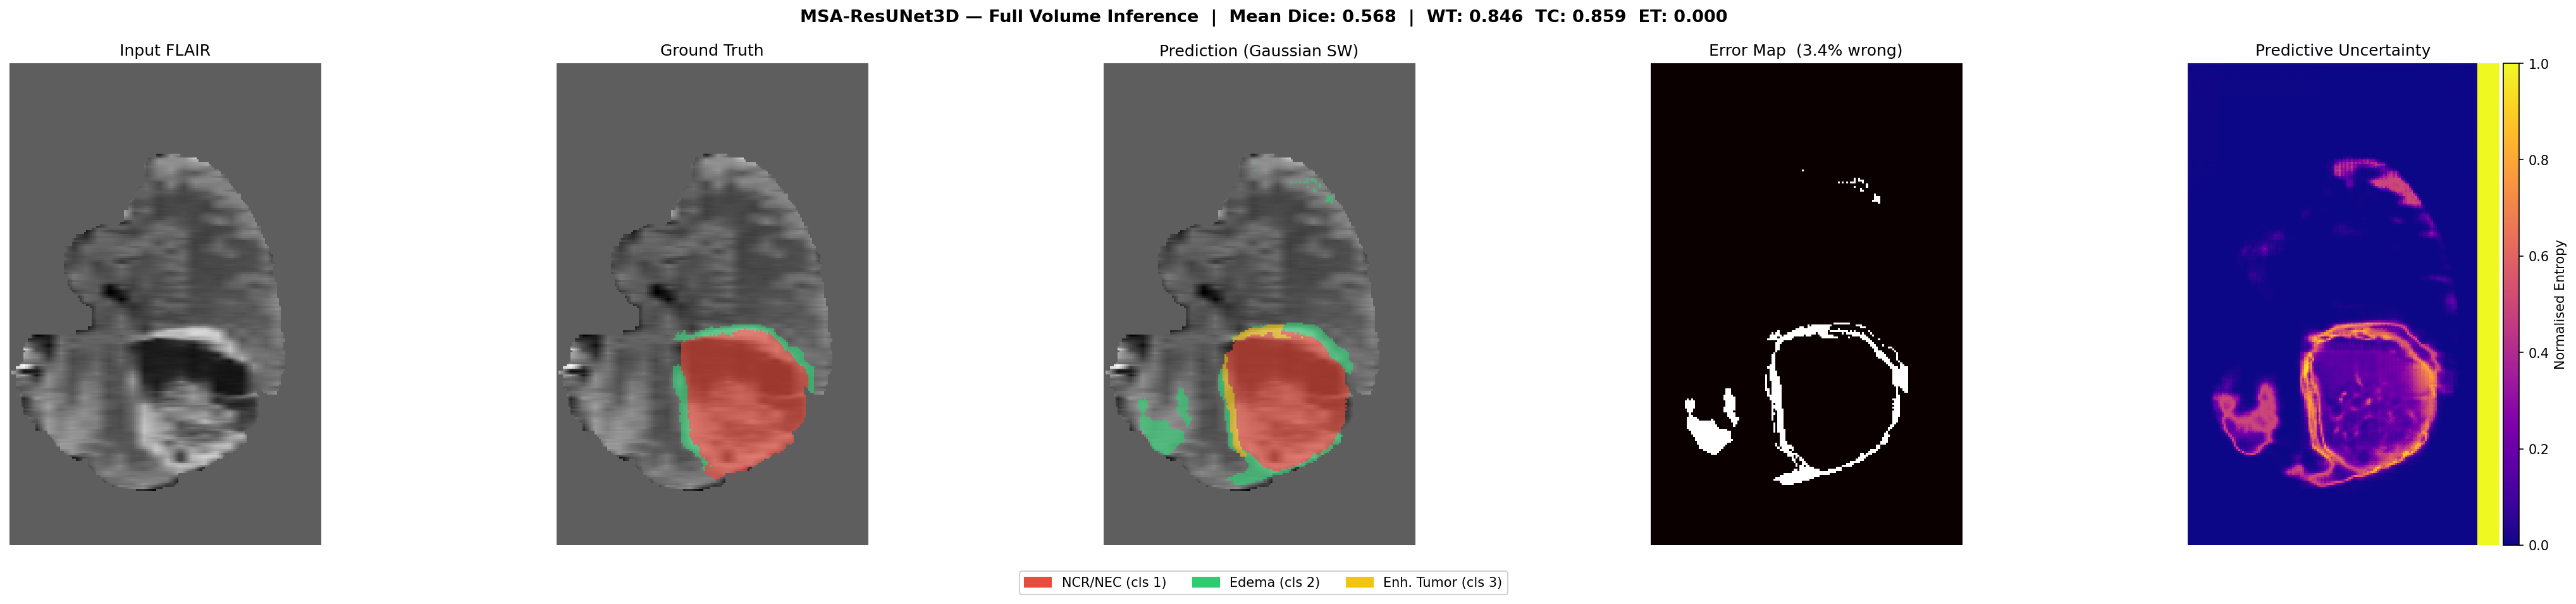

[Figure 3] BraTS Region Breakdown


KeyboardInterrupt: 

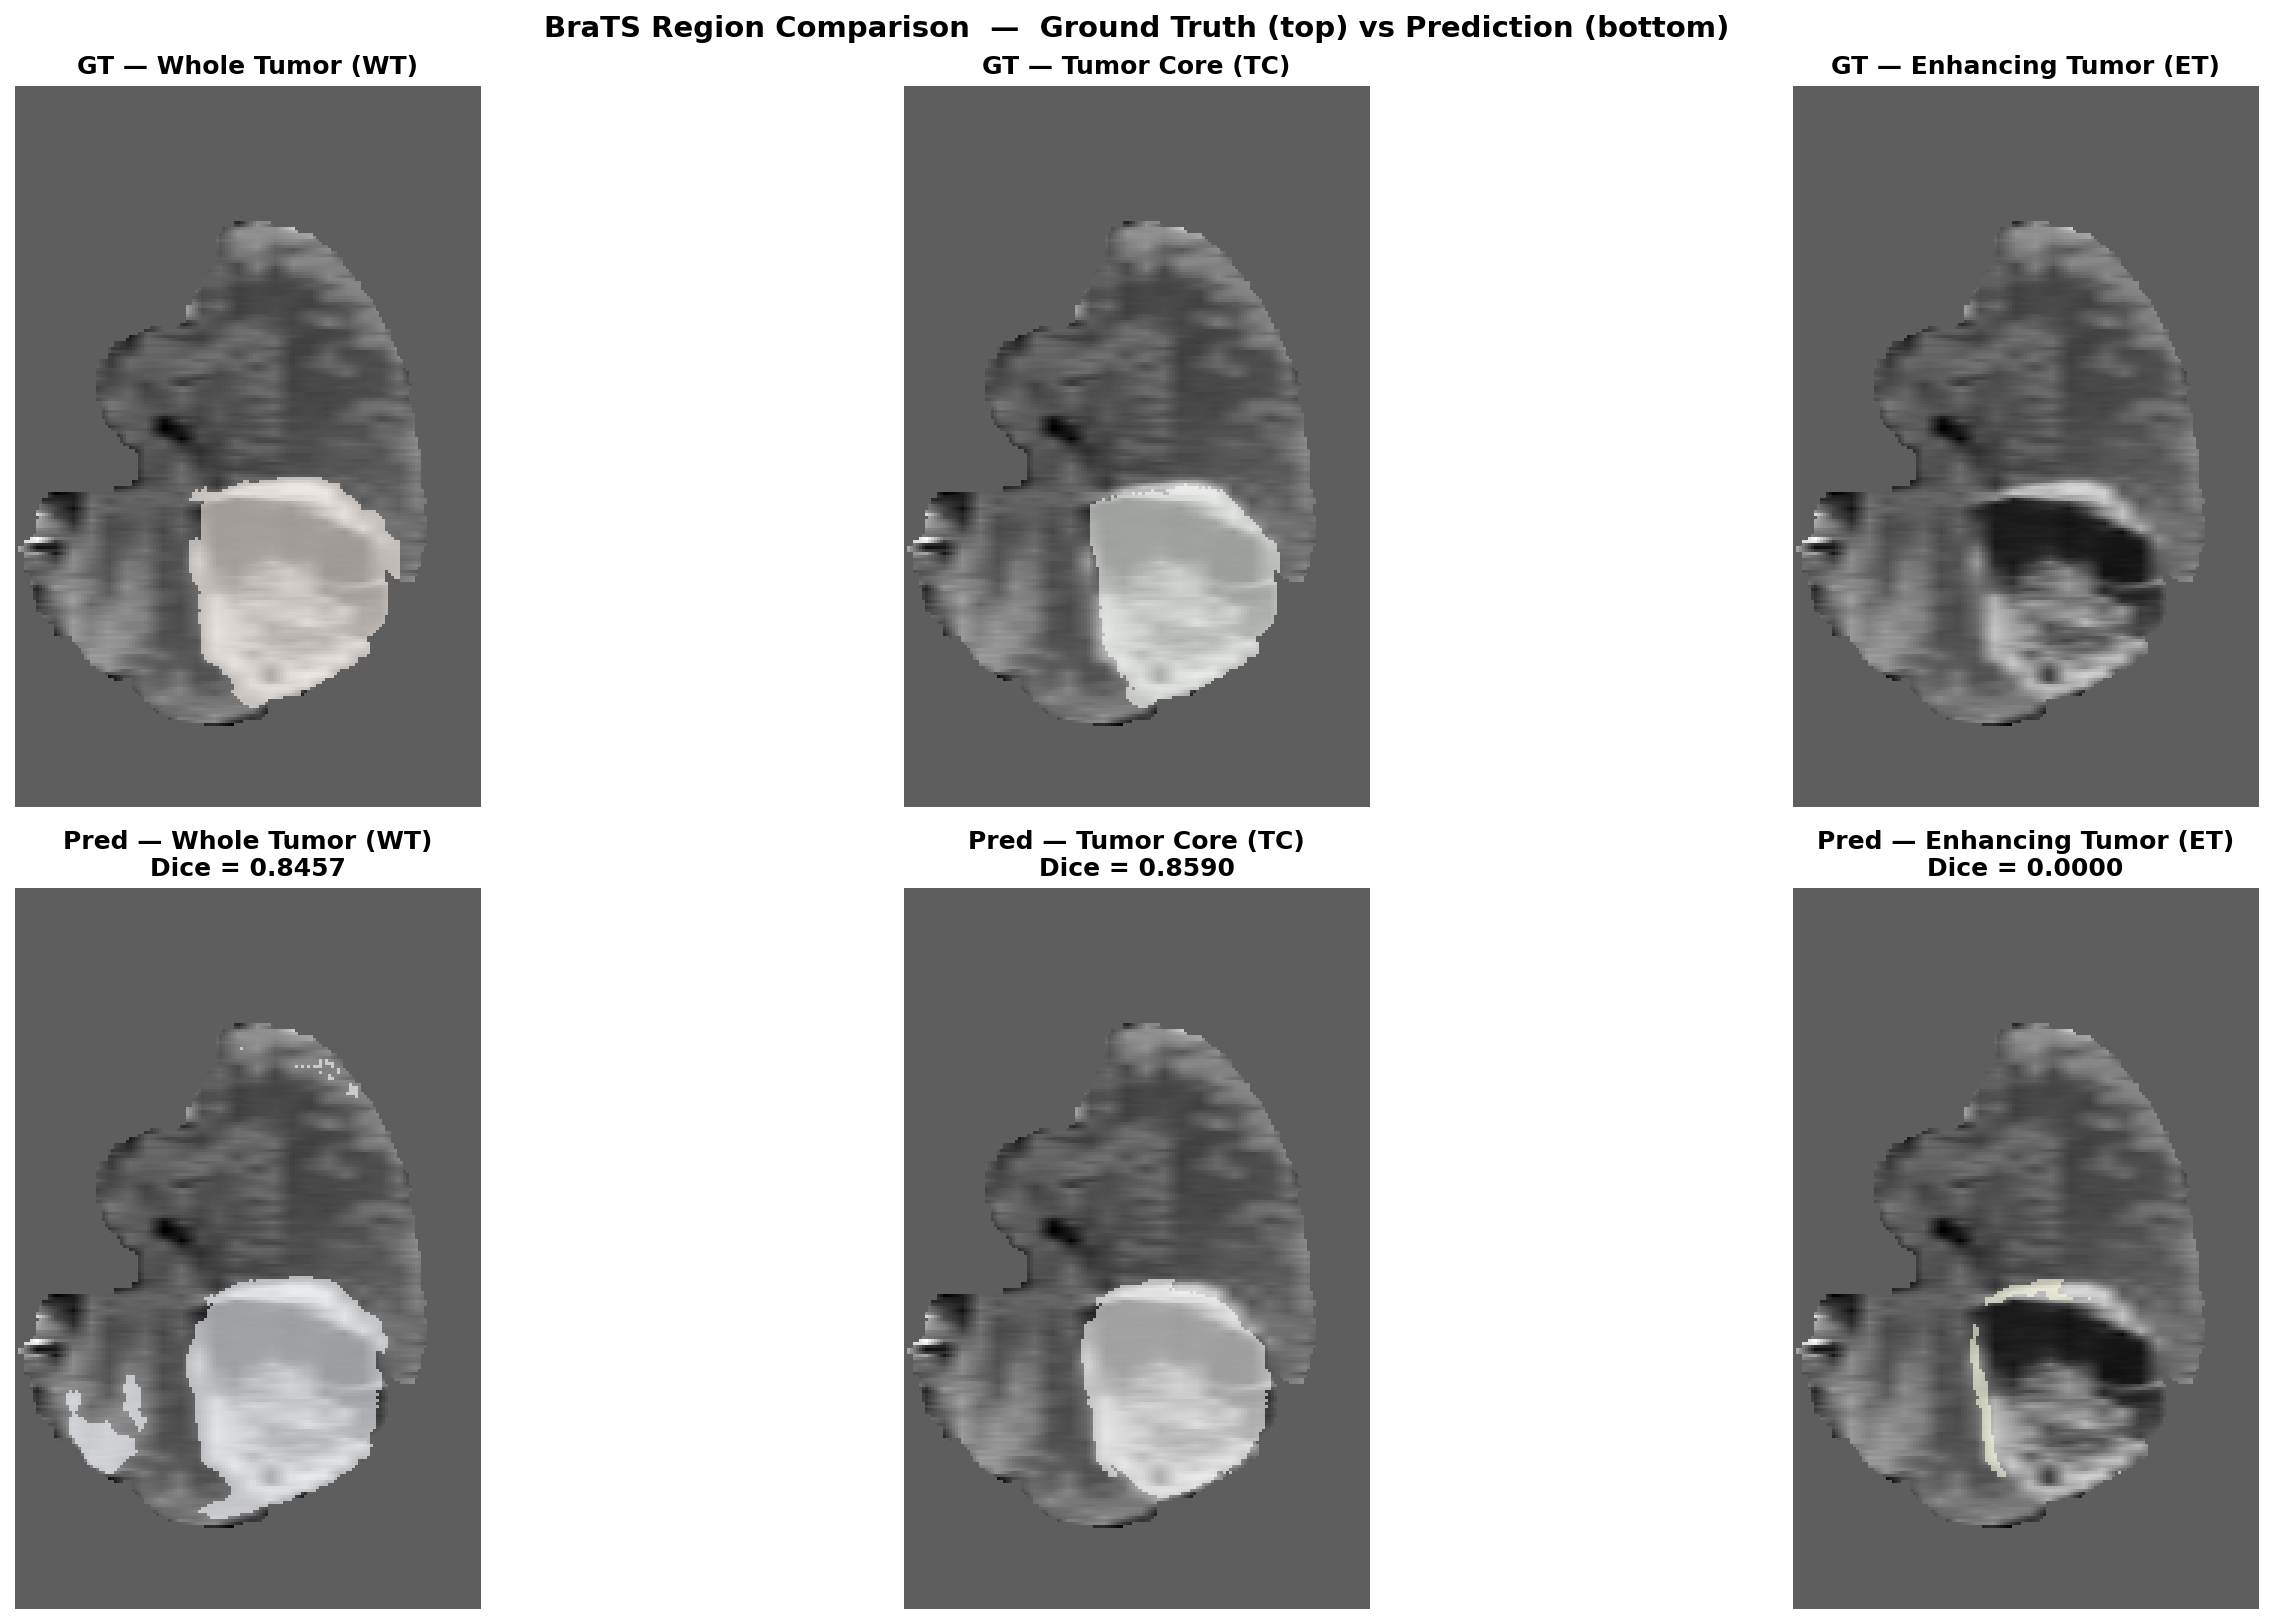

In [44]:
 for idx in range(min(3, len(val_ds))):
     print(f"\n{'='*60}")
     print(f"  Patient {idx+1}")
     print(f"{'='*60}") 
     research_visualize(raw_model, val_ds, sample_idx=idx, save_figs=True)
